# Feature Engineering

---

**Dataset:** [Nombre del dataset]


---

## Que buscamos en el Feature Engineering?

El EDA nos mostro **que tenemos**. El Feature Engineering define **como lo preparamos** para el modelo.
Sin esta etapa, hasta el mejor algoritmo produce resultados mediocres.

| Pregunta | Lo que haremos |
|---|---|
| Hay nulos que imputar? | Estrategias de imputacion segun tipo y porcentaje |
| Hay outliers que tratar? | Clipping, Winsorización, transformaciones |
| El target esta sesgado? | Transformacion logaritmica |
| Hay variables categoricas? | OHE, Ordinal Encoding, Target Encoding |
| Las escalas son comparables? | StandardScaler, MinMaxScaler, RobustScaler |
| Podemos crear variables nuevas? | Ratios, interacciones, extraccion de fechas |
| Hay variables redundantes? | Seleccion de features, correlacion |

---

### Como usar este documento

Cada paso viene con:
- **Explicacion teorica** de por que ese paso importa
- **Codigo listo para ejecutar** con comentarios detallados
- **Decision point** : si el paso aplica a tu dataset, ejecuta; si no, salta
- **Tabla de decisiones** para elegir la estrategia correcta

> **Regla de oro:** Nunca hagas transformaciones sin entender primero el dato.
> El EDA es el mapa; el Feature Engineering es la ruta.

---


---
## Paso 1 — Importar librerias

Cargamos todas las herramientas necesarias para el Feature Engineering.

| Libreria / Modulo | Para que la usamos |
|---|---|
| `pandas` / `numpy` | Manipulacion de datos y calculos numericos |
| `matplotlib` / `seaborn` | Visualizar el efecto de cada transformacion |
| `sklearn.impute` | Imputacion de nulos (Simple, KNN, Iterativo) |
| `sklearn.preprocessing` | Escalado, codificacion, transformacion de variables |
| `sklearn.feature_selection` | Seleccion automatica de features relevantes |
| `sklearn.pipeline` | Encadenar transformaciones de forma reproducible |
| `scipy.stats` | Tests estadisticos para validar transformaciones |

---


In [18]:
# ── Librerias ────────────────────────────────────────────────────
# ── Manipulacion de datos ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os

# ── Visualizacion ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Imputacion de valores faltantes ──────────────────────────────────────────
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer

# ── Escalado y normalizacion ──────────────────────────────────────────────────
from sklearn.preprocessing import (
    StandardScaler,      # Z-score: media=0, std=1
    MinMaxScaler,        # Rango [0,1] o personalizado
    RobustScaler,        # Robusto ante outliers (usa IQR)
    PowerTransformer,    # Box-Cox / Yeo-Johnson para normalizar distribuciones
    QuantileTransformer, # Transforma a distribucion uniforme o normal
)

# ── Codificacion de variables categoricas ─────────────────────────────────────
from sklearn.preprocessing import (
    OneHotEncoder,       # Crea columnas binarias (0/1) por cada categoria
    OrdinalEncoder,      # Asigna numeros segun orden definido
    LabelEncoder,        # Codifica una columna con enteros (no recomendado para features)
)

# ── Seleccion de features ──────────────────────────────────────────────────────
from sklearn.feature_selection import (
    SelectKBest,         # Selecciona las K mejores features segun un test estadistico
    f_regression,        # Test F para regresion (variables continuas)
    f_classif,           # Test F para clasificacion
    mutual_info_regression, # Informacion mutua para regresion (captura relaciones no lineales)
    VarianceThreshold,   # Elimina features con varianza muy baja (casi constantes)
    RFE,                 # Recursive Feature Elimination con un modelo base
)

# ── Pipeline y ColumnTransformer ─────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Estadistica ──────────────────────────────────────────────────────────────
from scipy import stats

# ── Configuraciones globales ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerias cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')


Librerias cargadas correctamente
   pandas  3.0.2
   numpy   2.4.4
   seaborn 0.13.2


---
## Paso 2 — Cargar los datos

Cargamos el dataset **tal como salio del EDA**, sin transformaciones previas.
A partir de este punto construimos el dataset limpio y enriquecido.

**Buenas practicas al iniciar el FE:**
- Trabajar siempre sobre una **copia** (`df.copy()`), nunca sobre el original
- Definir desde el inicio cuales son las columnas numericas, categoricas y de fecha
- Separar el target de las features antes de cualquier transformacion
- Documentar cada decision tomada

---


In [19]:
# ── Configuracion ────────────────────────────────────────────────────
RUTA_CSV = "melb_data.csv"
TARGET_COL = 'Price'

In [20]:
# ── Cargar el dataset ────────────────────────────────────────────────────────

df_raw = pd.read_csv(RUTA_CSV)

# Trabajamos siempre sobre una COPIA para no perder los datos originales
# Si en algun paso algo sale mal, puedes hacer df = df_raw.copy() y empezar de nuevo
df = df_raw.copy()

print('Datos cargados correctamente')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')


Datos cargados correctamente
   Filas    : 13,580
   Columnas : 21


In [21]:
# ── Encabezado del Dataset ─────────────────────────────────────────────
# Muestra las primeras filas para entender la estructura del dataset
display(df.head())

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0000,S,Biggin,3/12/2016,2.5000,3067.0000,2.0000,1.0000,1.0000,202.0000,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0000
1,Abbotsford,25 Bloomburg St,2,h,1035000.0000,S,Biggin,4/02/2016,2.5000,3067.0000,2.0000,1.0000,0.0000,156.0000,79.0000,1900.0000,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0000
2,Abbotsford,5 Charles St,3,h,1465000.0000,SP,Biggin,4/03/2017,2.5000,3067.0000,3.0000,2.0000,0.0000,134.0000,150.0000,1900.0000,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0000
3,Abbotsford,40 Federation La,3,h,850000.0000,PI,Biggin,4/03/2017,2.5000,3067.0000,3.0000,2.0000,1.0000,94.0000,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0000
4,Abbotsford,55a Park St,4,h,1600000.0000,VB,Nelson,4/06/2016,2.5000,3067.0000,3.0000,1.0000,2.0000,120.0000,142.0000,2014.0000,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0000


In [22]:
# ── Tipo dataos Iniciales ─────────────────────────────────────────────
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

None

In [23]:
# DECISION POINT ── Convertir tipos de columnas ─────────────────────────────────────────────
# Esto es critico: un error de tipo (ej. un numero leido como texto)
# puede silenciosamente arruinar todo el pipeline de transformacion.

# Si el dataset tiene fechas como texto, conviertelas AQUI:
# df['fecha_col'] = pd.to_datetime(df['fecha_col'], dayfirst=True, errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# si el dataset tiene columnas numericas leidas como texto, conviertelas AQUI:
# df['num_col'] = pd.to_numeric(df['num_col'], errors='coerce')

# si el dataset tiene columnas categoricas con numeros, conviertelas AQUI:
# Primero manejamos los nulos, luego convertimos a string y finalmente a categorica
# df['YearBuilt'] = df['YearBuilt'].fillna('Desconocido')  # O usa otro valor como 'Unknown' o un año específico
# df['YearBuilt'] = df['YearBuilt'].astype(int).astype(str)


In [24]:
# ── Clasificar columnas por tipo ─────────────────────────────────────────────
# Definimos desde el inicio que tipo tiene cada columna.

# Columnas numericas (int64, float64)
num_cols = df.select_dtypes(include='number').columns.tolist()

# Columnas categoricas (object, category)
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Columnas de fecha (si las hay)
date_cols = df.select_dtypes(include='datetime').columns.tolist()

# Remover el target de la lista de numericas para no transformarlo junto con las features
if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

print(f'Columnas numericas  ({len(num_cols)}): {num_cols}')
print(f'Columnas categoricas ({len(cat_cols)}): {cat_cols}')
print(f'Columnas de fecha   ({len(date_cols)}): {date_cols}')
print(f'Target: {TARGET_COL}')


Columnas numericas  (12): ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
Columnas categoricas (7): ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']
Columnas de fecha   (1): ['Date']
Target: Price


In [25]:
# ── Encabezado del Dataset Despues de cambio tipo datos─────────────────────────────────────────────
# Muestra las primeras filas para entender la estructura del dataset
display(df.head())

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0000,S,Biggin,2016-12-03,2.5000,3067.0000,2.0000,1.0000,1.0000,202.0000,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0000
1,Abbotsford,25 Bloomburg St,2,h,1035000.0000,S,Biggin,2016-02-04,2.5000,3067.0000,2.0000,1.0000,0.0000,156.0000,79.0000,1900.0000,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0000
2,Abbotsford,5 Charles St,3,h,1465000.0000,SP,Biggin,2017-03-04,2.5000,3067.0000,3.0000,2.0000,0.0000,134.0000,150.0000,1900.0000,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0000
3,Abbotsford,40 Federation La,3,h,850000.0000,PI,Biggin,2017-03-04,2.5000,3067.0000,3.0000,2.0000,1.0000,94.0000,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0000
4,Abbotsford,55a Park St,4,h,1600000.0000,VB,Nelson,2016-06-04,2.5000,3067.0000,3.0000,1.0000,2.0000,120.0000,142.0000,2014.0000,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0000


In [26]:
# ── Resumen de estado del dataset (punto de partida) ────────────────────────
# Antes de cualquier transformacion, documentamos el estado inicial.
# Sirve como linea base para medir el efecto de cada paso.

faltantes_ini = pd.DataFrame({
    'Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo': df.dtypes
}).sort_values('Porcentaje (%)', ascending=False)

print('=== ESTADO INICIAL DEL DATASET ===')
print(f'Filas        : {df.shape[0]:,}')
print(f'Columnas     : {df.shape[1]}')
print(f'Con nulos    : {(faltantes_ini["Faltantes"] > 0).sum()} columnas')
print(f'Duplicados   : {df.duplicated().sum()}')
print()
display(faltantes_ini[faltantes_ini['Faltantes'] > 0])


=== ESTADO INICIAL DEL DATASET ===
Filas        : 13,580
Columnas     : 21
Con nulos    : 4 columnas
Duplicados   : 0



,Faltantes,Porcentaje (%),Tipo
BuildingArea,6450,47.5000,float64
YearBuilt,5375,39.5800,float64
CouncilArea,1369,10.0800,str
Car,62,0.4600,float64


---
## Paso 3 — Eliminar duplicados

Los registros duplicados son filas identicas (o casi identicas) que aparecen mas de una vez.
Si no se eliminan, el modelo **sobreajusta** a esos ejemplos repetidos y pierde capacidad de generalizacion.

**Regla practica:**
- Si el duplicado es identico en todas las columnas incluyendo el target → eliminar
- Si el duplicado tiene el mismo ID pero diferente target → es un conflicto de datos, investigar

| Situacion | Accion |
|---|---|
| Filas 100% identicas | `drop_duplicates()` |
| Mismo ID pero diferente target | Investigar la fuente del dato |
| Sin duplicados | Continuar al siguiente paso |

---


In [27]:
# ── Eliminar registros duplicados ────────────────────────────────────────────
# drop_duplicates() elimina filas que son identicas en TODAS las columnas.
# keep='first': conserva la primera ocurrencia y elimina las siguientes.
# subset=['col1','col2']: busca duplicados solo en esas columnas (si tienes ID unico).

n_antes = len(df)
duplicados = df.duplicated().sum()

if duplicados > 0:
    df = df.drop_duplicates(keep='first')
    print(f'Filas eliminadas por duplicacion : {duplicados:,}')
    print(f'Filas antes : {n_antes:,}  →  despues : {len(df):,}')
else:
    print('Sin registros duplicados. Continuamos.')


Sin registros duplicados. Continuamos.


---
## Paso 4 — Imputacion de valores faltantes

Los modelos de ML (excepto algunos basados en arboles) **no toleran valores nulos**.
Imputar es reemplazar los NaN por un valor estimado que preserve la estructura del dato.

**Tabla de decision: que estrategia usar?**

| % Faltantes | Tipo de variable | Estrategia recomendada |
|---|---|---|
| < 5% | Numerica | Mediana (robusta ante outliers) |
| < 5% | Categorica | Moda (valor mas frecuente) |
| 5% - 20% | Numerica | Mediana + columna indicadora binaria |
| 5% - 20% | Categorica | Categoria 'Desconocido' + columna indicadora binaria |
| 20% - 35% | Cualquiera | KNN Imputer o Iterative Imputer + indicador. Ojo! pasos aplicados en pipeline final |
| > 35% | Cualquiera | Candidata a eliminación Evaluar si vale la pena mantener la columna |

> **Regla de oro:** si usas el metodo KNN Imputer o Iterative Imputer Siempre haz `fit` del imputador **solo con datos de entrenamiento** (nunca con test).
> Si aun no has dividido train/test, aplica la logica en el pipeline final.

---


Columnas con valores faltantes: 4


,Faltantes,Porcentaje (%),Tipo
BuildingArea,6450,47.5000,float64
YearBuilt,5375,39.5800,float64
CouncilArea,1369,10.0800,str
Car,62,0.4600,float64


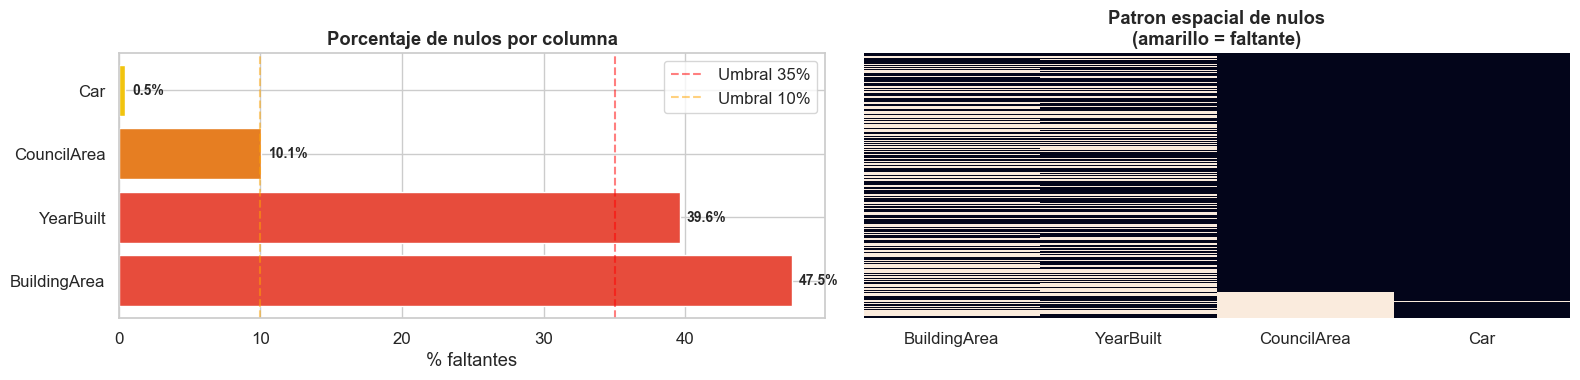

Rojo  -> >35% faltantes -> evaluar si mantener la columna
Naranja -> >10% faltantes -> imputar con cuidado + indicador binario
Amarillo -> <5% faltantes -> imputar directamente


In [28]:
# ── 4a. Diagnostico de nulos ─────────────────────────────────────────────────
# Antes de imputar, necesitamos saber exactamente cuanto y donde falta.
# El diagrama de calor (heatmap) muestra el patron espacial: si los nulos
# se concentran en filas concretas puede indicar un problema en la fuente.
UMBRAL_ROJO = 35  # Umbral para marcar en rojo las columnas con alto porcentaje de nulos
UMBRAL_NARANJA = 10  # Umbral para marcar en naranja las columnas con nulos moderados

faltantes = pd.DataFrame({
    'Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo': df.dtypes
}).sort_values('Porcentaje (%)', ascending=False)

faltantes_reales = faltantes[faltantes['Faltantes'] > 0]

if len(faltantes_reales) == 0:
    print('Sin valores faltantes. Puedes saltar al Paso 5.')
else:
    print(f'Columnas con valores faltantes: {len(faltantes_reales)}')
    display(faltantes_reales)

    # Mapa visual de nulos
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Barras de porcentaje
    colores = ['#e74c3c' if p > UMBRAL_ROJO else '#e67e22' if p > UMBRAL_NARANJA else '#f1c40f'
               for p in faltantes_reales['Porcentaje (%)']]
    bars = axes[0].barh(faltantes_reales.index, faltantes_reales['Porcentaje (%)'],
                        color=colores, edgecolor='white')
    for bar, pct in zip(bars, faltantes_reales['Porcentaje (%)']):
        axes[0].text(bar.get_width() + 0.5,
                     bar.get_y() + bar.get_height() / 2,
                     f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')
    axes[0].axvline(UMBRAL_ROJO, color='red', ls='--', alpha=0.5, label=f'Umbral {UMBRAL_ROJO}%')
    axes[0].axvline(UMBRAL_NARANJA,  color='orange', ls='--', alpha=0.5, label=f'Umbral {UMBRAL_NARANJA}%')
    axes[0].set_xlabel('% faltantes')
    axes[0].set_title('Porcentaje de nulos por columna', fontweight='bold')
    axes[0].legend()

    # Heatmap de patron de nulos
    sns.heatmap(df[faltantes_reales.index].isnull(),
                cbar=False, ax=axes[1], yticklabels=False)
    axes[1].set_title('Patron espacial de nulos\n(amarillo = faltante)', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f'Rojo  -> >{UMBRAL_ROJO}% faltantes -> evaluar si mantener la columna')
    print(f'Naranja -> >{UMBRAL_NARANJA}% faltantes -> imputar con cuidado + indicador binario')
    print('Amarillo -> <5% faltantes -> imputar directamente')


In [29]:
# ── 4b. Estrategia 1: Columnas con exceso de nulos >35% ────────────
# Si una columna tiene >35% de nulos, suele tener poco valor informativo.
# Mantenerla puede introducir ruido y dificultar la imputacion.
# DECISION: ajusta el umbral segun el contexto de negocio de tu proyecto.

UMBRAL_ELIMINAR = 35  # Porcentaje maximo de nulos aceptable

cols_a_eliminar = faltantes[faltantes['Porcentaje (%)'] > UMBRAL_ELIMINAR].index.tolist()

if cols_a_eliminar:
    print(f'Columnas con >{UMBRAL_ELIMINAR}% de nulos (candidatas a eliminar):')
    for col in cols_a_eliminar:
        pct = faltantes.loc[col, 'Porcentaje (%)']
        print(f'   {col:<25} {pct:.1f}%')

    print('\n-> Revisar si alguna de estas columnas es critica para el negocio.')
    print('   Ejecutar el drop para eliminarlas.')
else:
    print(f'Ninguna columna supera el {UMBRAL_ELIMINAR}% de nulos. Continuamos.')


Columnas con >35% de nulos (candidatas a eliminar):
   BuildingArea              47.5%
   YearBuilt                 39.6%

-> Revisar si alguna de estas columnas es critica para el negocio.
   Ejecutar el drop para eliminarlas.


In [ ]:
 # DECISION POINT── 4b. Estrategia 1: Columnas con exceso de nulos >35% ────────────
if cols_a_eliminar:

    for col in cols_a_eliminar:
        try:
            pct = faltantes.loc[col, 'Porcentaje (%)']
            df = df.drop(columns=[col])
        except KeyError:
            print(f'   Columna {col} no encontrada en el DataFrame')

    print(f'\nELIMINACION APLICADA: {len(cols_a_eliminar)} columna(s) eliminada(s): {cols_a_eliminar}')
else:
    print(f'Ninguna columna supera el {UMBRAL_ELIMINAR}% de nulos. Continuamos.')


   Eliminando BuildingArea              con 47.5% de nulos
   Eliminando YearBuilt                 con 39.6% de nulos

ELIMINACION APLICADA: 2 columna(s) eliminada(s): ['BuildingArea', 'YearBuilt']


In [31]:
# ── 4c. Estrategia 2: Crear Columna indicadora Binaria de nulos 5% y 20% ───────────────────────────
# Para columnas con nulos entre 5% y 20% , crear una columna binaria que
# indica si el valor ORIGINALMENTE era nulo. 
# Por que?:
#   - El hecho de que falte un dato puede ser informativo para el modelo
#   - Ejemplo: en inmobiliaria, que falte el numero de estacionamientos
#     puede indicar que la propiedad no tiene. Esa ausencia tiene significado.
#   - El modelo puede aprender que 'nulo en X' se asocia a un determinado target

UMBRAL_INDICADOR_MINIMO = 5  # Crear indicador si los nulos superan este porcentaje
UMBRAL_INDICADOR_MAXIMO = 20  # No crear indicador si los nulos superan este porcentaje

cols_con_indicador = faltantes[
    (faltantes['Porcentaje (%)'] > UMBRAL_INDICADOR_MINIMO) &
    (faltantes['Porcentaje (%)'] <= UMBRAL_INDICADOR_MAXIMO)
].index.tolist()

for col in cols_con_indicador:
    nombre_indicador = f'{col}_era_nulo'
    df[nombre_indicador] = df[col].isnull().astype(int)
    print(f'Indicador creado: {nombre_indicador}  (1=era nulo, 0=tenia valor)')

if not cols_con_indicador:
    print('Ninguna columna se ajusta para indicador de nulos con el umbral actual.')


Indicador creado: CouncilArea_era_nulo  (1=era nulo, 0=tenia valor)


In [32]:
# ── 4d. Estrategia 3: Imputacion de variables NUMERICAS SimpleImputer con mediana mayor a 0% hasta 20% nulos────────────────────────────────────
# Estrategia 1: SimpleImputer con mediana para columnas numericas con nulos entre 5% y 20%
#   - La mediana es robusta: no se ve afectada por outliers extremos
#   - Preferida sobre la media cuando hay outliers (como en precios, ingresos)
#   - strategy='mean': usa el promedio (solo si la distribucion es simetrica)
#   - strategy='constant': rellena con un valor fijo (ej. 0)
#   - CUANDO USAR: cuando los nulos son aleatorios y el porcentaje es bajo

# Codigo:
UMBRAL_INDICADOR_MINIMO = 0  # Crear indicador si los nulos superan este porcentaje
UMBRAL_INDICADOR_MAXIMO = 20  # No crear indicador si los nulos superan este porcentaje

num_nulas = [c for c in num_cols if c in faltantes_reales.index and faltantes_reales.loc[c, 'Porcentaje (%)'] > UMBRAL_INDICADOR_MINIMO and faltantes_reales.loc[c, 'Porcentaje (%)'] <= UMBRAL_INDICADOR_MAXIMO]

if num_nulas:
    print('Imputando variables numericas con la MEDIANA:')
    imputer_num = SimpleImputer(strategy='median')
    df[num_nulas] = imputer_num.fit_transform(df[num_nulas])

    for col, val in zip(num_nulas, imputer_num.statistics_):
        print(f'   {col:<25} imputado con mediana = {val:.4f}')
else:
    print('No hay columnas numericas con nulos. Continuamos.')


Imputando variables numericas con la MEDIANA:
   Car                       imputado con mediana = 2.0000


In [33]:
# ── 4e. Imputacion de variables CATEGORICAS <=5% (Moda), >5% (Desconocido) ──
# Para categoricas hay dos enfoques principales:
#   1. Moda: simple, funciona bien con pocos nulos
#   2. Nueva categoria 'Desconocido': util cuando la ausencia es informativa
#
# NOTA: se detectan automaticamente las categoricas con nulos.
# Si quieres limitar a columnas especificas, reemplaza la linea de cat_nulas:
# Ejemplo Melbourne: cat_nulas = ['CouncilArea']

UMBRAL_INDICADOR_MINIMO = 5  # Crear indicador si los nulos superan este porcentaje
UMBRAL_INDICADOR_MAXIMO = 20  # No crear indicador si los nulos superan este porcentaje

cat_nulas = [c for c in cat_cols if c in faltantes_reales.index]

if cat_nulas:
    print('Imputando variables categoricas:')
    for col in cat_nulas:
        pct_nulo = faltantes.loc[col, 'Porcentaje (%)']
        if pct_nulo <= UMBRAL_INDICADOR_MINIMO:
            moda = df[col].mode()[0]
            df[col] = df[col].fillna(moda)
            print(f'   {col:<25} imputado con moda = "{moda}"')
        elif pct_nulo <= UMBRAL_INDICADOR_MAXIMO:
            df[col] = df[col].fillna('Desconocido')
            print(f'   {col:<25} imputado con categoria "Desconocido"')
        else:
            print(f'   {col:<25} no se imputa porque supera el {UMBRAL_INDICADOR_MAXIMO}% de nulos')
else:
    print('No hay columnas categoricas con nulos. Continuamos.')


Imputando variables categoricas:
   CouncilArea               imputado con categoria "Desconocido"


In [34]:
# ── Verificar que no quedan nulos ────────────────────────────────────────────
nulos_restantes = df.isnull().sum().sum()
if nulos_restantes == 0:
    print('Verificacion completa: sin valores nulos restantes')
else:
    print(f'AVISO: quedan {nulos_restantes} nulos en el dataset')
    print('si quedan columnas con nulos, y el porcentaje de nulos esta entre 20% y 35%, considera usar KNN Imputer en el paso 3a de modelado, ' \
    'o eliminar la columna')
    print(df.isnull().sum()[df.isnull().sum() > 0])

Verificacion completa: sin valores nulos restantes


---
## Paso 5 — Tratamiento de Outliers

Los outliers son valores que se alejan significativamente del resto. El EDA los identifico; aqui decidimos **que hacer con ellos**.

**Tabla de decision: como tratar un outlier?**

| Situacion | Estrategia | Cuando usarla |
|---|---|---|
| Error de captura evidente | Eliminar la fila | Muy raro, solo cuando es claro |
| Valor extremo real | Clipping / Winsorización | Cuando el extremo distorsiona el modelo |
| Distribucion muy sesgada | Transformacion log / raiz | Variables de precio, ingreso, area |
| Modelo robusto (arboles) | Mantener | Random Forest, XGBoost los manejan bien |

> **Regla de oro:** Antes de eliminar un outlier, pregunta si es un error o un dato real.
> Un precio de mansión de $10M en un dataset de viviendas es raro, pero real.

---


In [35]:
# ── 5a. Identificar outliers con el metodo IQR ──────────────────────────────
# IQR = Q3 - Q1 (rango intercuartil: el ancho del 50% central de los datos)
# Limite inferior = Q1 - 1.5 * IQR
# Limite superior = Q3 + 1.5 * IQR
# Cualquier valor fuera de estos limites es un outlier

num_cols = [col for col in num_cols if col in df.columns]  # Asegurarnos de usar solo las columnas que quedan

def calcular_outliers_iqr(serie):
    """Calcula limites IQR y cuenta outliers en una serie numerica."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lim. inf': lim_inf, 'Lim. sup': lim_sup,
        'N outliers': n_out,
        '% outliers': round(n_out / len(serie) * 100, 2)
    })

tabla_outliers = (
    df[num_cols].apply(lambda col: calcular_outliers_iqr(col.dropna()))
    .T.sort_values('% outliers', ascending=False)
)

print('Tabla de outliers por columna (metodo IQR):')
display(tabla_outliers.style.background_gradient(subset=['% outliers'], cmap='Reds').format(precision=2))



Tabla de outliers por columna (metodo IQR):


,Q1,Q3,IQR,Lim. inf,Lim. sup,N outliers,% outliers
Rooms,2.00,3.00,1.00,0.50,4.50,682.00,5.02
Bedroom2,2.00,3.00,1.00,0.50,4.50,655.00,4.82
Car,1.00,2.00,1.00,-0.50,3.50,644.00,4.74
Distance,6.10,13.00,6.90,-4.25,23.35,411.00,3.03
Longtitude,144.93,145.06,0.13,144.74,145.25,408.00,3.00
Landsize,177.00,651.00,474.00,-534.00,1362.00,368.00,2.71
Propertycount,4380.00,10331.00,5951.00,-4546.50,19257.50,359.00,2.64
Lattitude,-37.86,-37.76,0.10,-38.01,-37.61,262.00,1.93
Postcode,3044.00,3148.00,104.00,2888.00,3304.00,208.00,1.53
Bathroom,1.00,2.00,1.00,-0.50,3.50,143.00,1.05


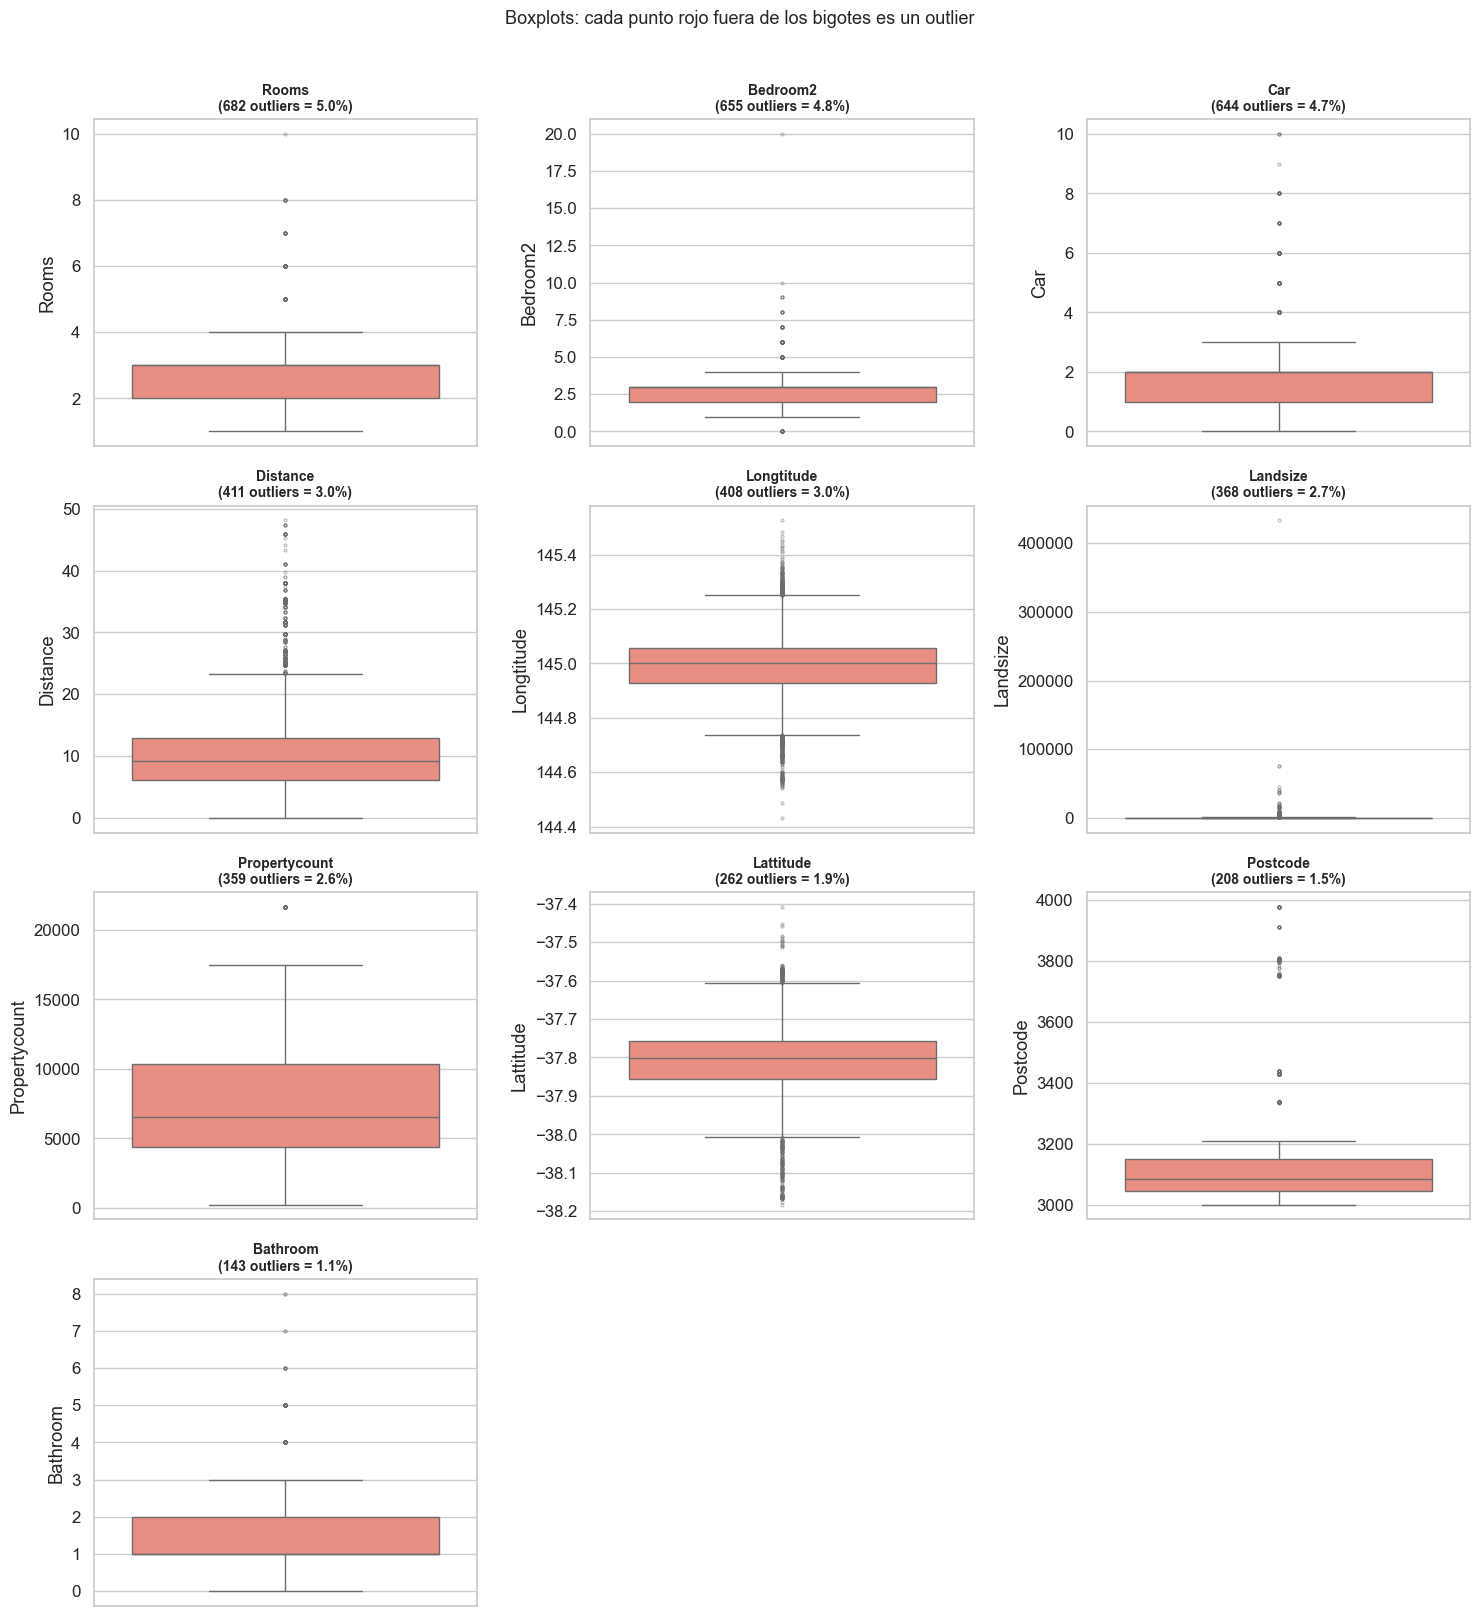

In [36]:
# ── 5b. Visualizar outliers con boxplots ────────────────────────────────────
# El boxplot muestra la caja (IQR), la mediana y los puntos que salen de los bigotes.
# Cada punto rojo es un outlier identificado por el metodo IQR.

cols_con_out = tabla_outliers[tabla_outliers['N outliers'] > 0].index.tolist()
# display(cols_con_out)

if cols_con_out:
    ncols = 3
    nrows = (len(cols_con_out) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols_con_out):
        sns.boxplot(y=df[col].dropna(), ax=axes[i], color='salmon',
                    flierprops=dict(marker='.', color='crimson', alpha=0.4, markersize=4))
        n_out = int(tabla_outliers.loc[col, 'N outliers'])
        pct = tabla_outliers.loc[col, '% outliers']
        axes[i].set_title(f'{col}\n({n_out} outliers = {pct:.1f}%)',
                          fontweight='bold', fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Boxplots: cada punto rojo fuera de los bigotes es un outlier',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No se detectaron outliers. Continuamos.')


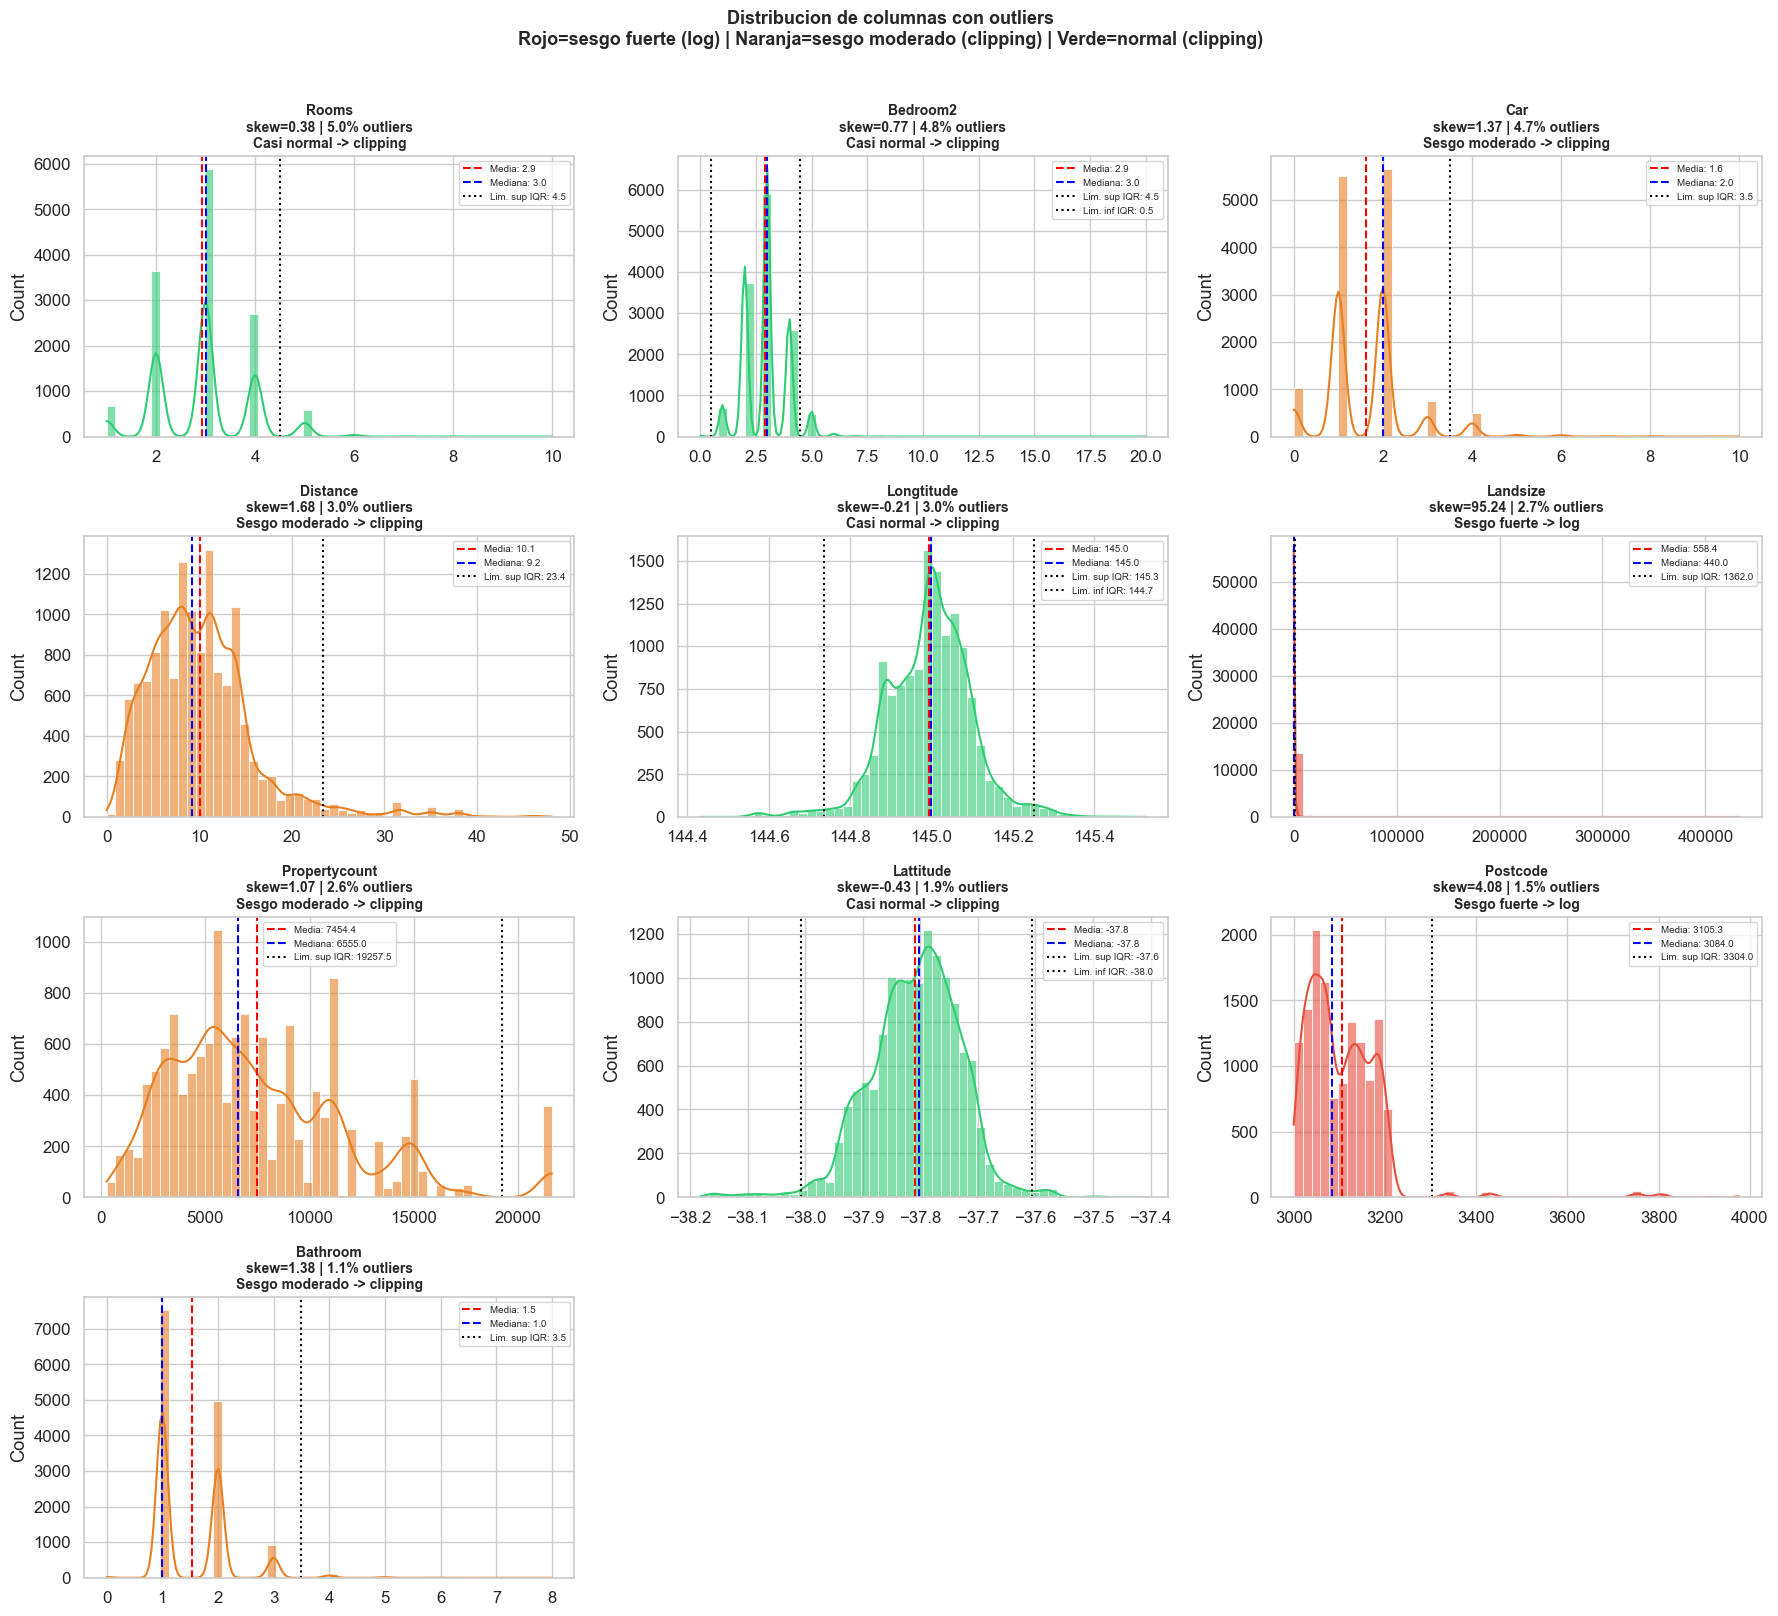

=== DIAGNOSTICO DE SESGO POR COLUMNA ===
Columna                     Skewness   % Outliers Accion sugerida               
--------------------------------------------------------------------------------
Rooms                          0.376         5.0% Clipping IQR                  
Bedroom2                       0.774         4.8% Clipping IQR                  
Car                            1.366         4.7% Clipping o transformacion     
Distance                       1.677         3.0% Clipping o transformacion     
Longtitude                    -0.211         3.0% Clipping IQR                  
Landsize                      95.237         2.7% Transformacion log (log1p)    
Propertycount                  1.069         2.6% Clipping o transformacion     
Lattitude                     -0.427         1.9% Clipping IQR                  
Postcode                       4.076         1.5% Transformacion log (log1p)    
Bathroom                       1.377         1.1% Clipping o transfo

In [37]:
# ── 5b2. Visualizar distribucion de columnas con outliers ────────────────────
# El boxplot nos dice CUANTOS outliers hay. Este grafico nos dice POR QUE existen:
#   - Distribucion normal con outliers reales -> tratar con clipping
#   - Distribucion sesgada a la derecha (cola larga) -> considerar transformacion log
#   - Distribucion bimodal (dos picos) -> puede indicar dos poblaciones mezcladas

if cols_con_out:
    ncols = 3
    nrows = (len(cols_con_out) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols_con_out):
        serie = df[col].dropna()
        skew_val = serie.skew()

        # Color segun nivel de sesgo
        if abs(skew_val) > 2:
            color = '#e74c3c'       # rojo: sesgo fuerte -> considerar transformacion log
            diagnostico = 'Sesgo fuerte -> log'
        elif abs(skew_val) > 1:
            color = '#e67e22'       # naranja: sesgo moderado -> evaluar clipping
            diagnostico = 'Sesgo moderado -> clipping'
        else:
            color = '#2ecc71'       # verde: distribucion casi normal -> clipping
            diagnostico = 'Casi normal -> clipping'

        # Histograma con KDE
        sns.histplot(serie, ax=axes[i], kde=True, color=color, bins=50, alpha=0.6)

        # Lineas de media y mediana
        axes[i].axvline(serie.mean(),   color='red',   ls='--', lw=1.5,
                        label=f'Media: {serie.mean():.1f}')
        axes[i].axvline(serie.median(), color='blue',  ls='--', lw=1.5,
                        label=f'Mediana: {serie.median():.1f}')

        # Limites IQR (donde empieza la zona de outliers)
        lim_inf = tabla_outliers.loc[col, 'Lim. inf']
        lim_sup = tabla_outliers.loc[col, 'Lim. sup']
        axes[i].axvline(lim_sup, color='black', ls=':', lw=1.5,
                        label=f'Lim. sup IQR: {lim_sup:.1f}')
        if lim_inf > serie.min():
            axes[i].axvline(lim_inf, color='black', ls=':', lw=1.5,
                            label=f'Lim. inf IQR: {lim_inf:.1f}')

        # Titulo con diagnostico
        pct = tabla_outliers.loc[col, '% outliers']
        axes[i].set_title(
            f'{col}\nskew={skew_val:.2f} | {pct:.1f}% outliers\n{diagnostico}',
            fontweight='bold', fontsize=10
        )
        axes[i].legend(fontsize=7)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        'Distribucion de columnas con outliers\n'
        'Rojo=sesgo fuerte (log) | Naranja=sesgo moderado (clipping) | Verde=normal (clipping)',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    # Resumen de diagnosticos
    print('=== DIAGNOSTICO DE SESGO POR COLUMNA ===')
    print(f'{"Columna":<25} {"Skewness":>10} {"% Outliers":>12} {"Accion sugerida":<30}')
    print('-' * 80)
    for col in cols_con_out:
        serie    = df[col].dropna()
        skew_val = serie.skew()
        pct      = tabla_outliers.loc[col, '% outliers']
        if abs(skew_val) > 2:
            accion = 'Transformacion log (log1p)'
        elif abs(skew_val) > 1:
            accion = 'Clipping o transformacion'
        else:
            accion = 'Clipping IQR'
        print(f'{col:<25} {skew_val:>10.3f} {pct:>11.1f}% {accion:<30}')
else:
    print('No se detectaron outliers. No hay distribuciones que analizar.')



In [38]:
# DECISION POINT ── 5c. Estrategia 1: Clipping / Winsorización ──────────────────────────────
# Clipping: reemplaza los valores extremos por los limites IQR.
# NO elimina datos, solo los 'recorta' al limite superior/inferior.
# Ventaja: no pierde filas, solo suaviza los extremos.
# Ideal cuando: los outliers son valores reales pero muy extremos.

UMBRAL_OUTLIERS = 2  # Aplicar clipping solo a columnas con mas de este porcentaje de outliers

# DECISION POINT: define cuales columnas quieres clippear
cols_clipping = ['Rooms', 'Bedroom2', 'Car', 'Distance', 'Longtitude', 'Propertycount', 'Lattitude', 'Bathroom']  # <-- CAMBIA ESTO
print('aplicando clipping a columnas especificas')

# Ejemplo: clipping sobre todas las columnas con >2% de outliers
# cols_clipping = tabla_outliers[tabla_outliers['% outliers'] > UMBRAL_OUTLIERS].index.tolist() # aplicar a todos con mas de UMBRAL_OUTLIERS% de outliers
# print(f'aplicando clipping a columnas con mas de {UMBRAL_OUTLIERS}% de outliers')

for col in cols_clipping:
    lim_inf = tabla_outliers.loc[col, 'Lim. inf']
    lim_sup = tabla_outliers.loc[col, 'Lim. sup']
    n_antes = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()

    # Aplicar clipping
    # DECISION POINT: descomenta la siguiente linea cuando quieras aplicarlo
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    print(f'   {col:<25} lim: [{lim_inf:.2f}, {lim_sup:.2f}]  afecta: {n_antes} valores')



aplicando clipping a columnas especificas
   Rooms                     lim: [0.50, 4.50]  afecta: 682 valores
   Bedroom2                  lim: [0.50, 4.50]  afecta: 655 valores
   Car                       lim: [-0.50, 3.50]  afecta: 644 valores
   Distance                  lim: [-4.25, 23.35]  afecta: 411 valores
   Longtitude                lim: [144.74, 145.25]  afecta: 408 valores
   Propertycount             lim: [-4546.50, 19257.50]  afecta: 359 valores
   Lattitude                 lim: [-38.01, -37.61]  afecta: 262 valores
   Bathroom                  lim: [-0.50, 3.50]  afecta: 143 valores


In [39]:
# # DECISION POINT ── 5c. Estrategia 2: Transformacion Log Raiz ──────────────────────────────
# # La transformacion logaritmica o raiz puede reducir la influencia de outliers.
# # Es especialmente util para variables con distribucion sesgada a la derecha (long tail).
# # Al aplicar log o raiz, los valores grandes se comprimen mas que los pequeños,
# # lo que puede mejorar la relacion con el target y el rendimiento del modelo.

# DECISION POINT: define cuales columnas quieres transformar
cols_log = ['Landsize', 'Postcode']  # <-- CAMBIA ESTO
print('aplicando transformacion log a columnas especificas')

# # Ejemplo: aplicar logaritmo a las columnas con >2% de outliers
# # cols_log = tabla_outliers[tabla_outliers['% outliers'] > 2].index.tolist() # aplicar a todos los que tengan outliers


for col in cols_log:
    n_antes = (df[col] > 0).sum()  # Solo se pueden logaritmar valores positivos

    # DECISION POINT: descomenta la siguiente linea para aplicar logaritmo
    df[col] = np.log1p(df[col])  # log1p = log(1 + x) para manejar ceros

    print(f'   {col:<25} valores >0: {n_antes} (log solo se aplica a estos)')


aplicando transformacion log a columnas especificas
   Landsize                  valores >0: 11641 (log solo se aplica a estos)
   Postcode                  valores >0: 13580 (log solo se aplica a estos)


In [40]:
# ── 5d. Validacion final columnas con outliers ──────────────────────────────
# IQR = Q3 - Q1 (rango intercuartil: el ancho del 50% central de los datos)
# Limite inferior = Q1 - 1.5 * IQR
# Limite superior = Q3 + 1.5 * IQR
# Cualquier valor fuera de estos limites es un outlier

num_cols = [col for col in num_cols if col in df.columns]  # Asegurarnos de usar solo las columnas que quedan

def calcular_outliers_iqr(serie):
    """Calcula limites IQR y cuenta outliers en una serie numerica."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lim. inf': lim_inf, 'Lim. sup': lim_sup,
        'N outliers': n_out,
        '% outliers': round(n_out / len(serie) * 100, 2)
    })

tabla_outliers = (
    df[num_cols].apply(lambda col: calcular_outliers_iqr(col.dropna()))
    .T.sort_values('% outliers', ascending=False)
)

print('Tabla de % final de outliers por columna:')
display(tabla_outliers.style.background_gradient(subset=['% outliers'], cmap='Reds').format(precision=2))

Tabla de % final de outliers por columna:


,Q1,Q3,IQR,Lim. inf,Lim. sup,N outliers,% outliers
Landsize,5.18,6.48,1.30,3.23,8.43,2024.00,14.90
Postcode,8.02,8.05,0.03,7.97,8.11,208.00,1.53
Distance,6.10,13.00,6.90,-4.25,23.35,0.00,0.00
Rooms,2.00,3.00,1.00,0.50,4.50,0.00,0.00
Bathroom,1.00,2.00,1.00,-0.50,3.50,0.00,0.00
Bedroom2,2.00,3.00,1.00,0.50,4.50,0.00,0.00
Car,1.00,2.00,1.00,-0.50,3.50,0.00,0.00
Lattitude,-37.86,-37.76,0.10,-38.01,-37.61,0.00,0.00
Longtitude,144.93,145.06,0.13,144.74,145.25,0.00,0.00
Propertycount,4380.00,10331.00,5951.00,-4546.50,19257.50,0.00,0.00


---
## Paso 6 — Transformacion del Target (variable objetivo)

**Solo para regresion.** Si tu problema es clasificacion, salta este paso.

Los modelos de regresion lineal asumen que los errores tienen distribucion normal.
Si el target esta muy sesgado (comun en precios, ingresos, areas), esta asuncion
se viola y el modelo pierde precision.

**Opciones de transformacion:**

| Transformacion | Formula | Cuando usarla |
|---|---|---|
| Log natural | `log(x)` | Datos estrictamente positivos, sesgo fuerte |
| Log1p | `log(1+x)` | Si hay ceros en los datos |
| Raiz cuadrada | `sqrt(x)` | Sesgo moderado, datos no negativos |
| Box-Cox | Optimiza automaticamente | Datos estrictamente positivos |
| Yeo-Johnson | Extiende Box-Cox | Acepta datos negativos |

> **Importante:** despues de predecir, aplicas la transformacion inversa para
> obtener el valor real. `log` -> `exp`, `log1p` -> `expm1`, etc.

---


In [41]:
# ── 6a. Analizar la distribucion actual del target ───────────────────────────
# Primero verificamos si el target necesita transformacion.
# Un skewness |s| > 1 es senal de que la transformacion puede ayudar.

target = df[TARGET_COL].dropna()

print(f'=== ANALISIS DEL TARGET: {TARGET_COL} ===')
print(f'  N registros : {len(target):,}')
print(f'  Media       : {target.mean():.4f}')
print(f'  Mediana     : {target.median():.4f}')
print(f'  Diferencia  : {target.mean() - target.median():.4f}')
print(f'  Skewness    : {target.skew():.4f}  ->  {"AVISO: muy sesgado" if abs(target.skew()) > 1 else "OK"}')
print(f'  Kurtosis    : {target.kurtosis():.4f}')

if target.mean() > target.median():
    print(f'\nLa media es MAYOR que la mediana: sesgo a la derecha.')
    print('   Considera transformacion logaritmica si el skewness es > 1.')
else:
    print(f'\nLa media es MENOR que la mediana: sesgo a la izquierda.')


=== ANALISIS DEL TARGET: Price ===
  N registros : 13,580
  Media       : 1075684.0795
  Mediana     : 903000.0000
  Diferencia  : 172684.0795
  Skewness    : 2.2396  ->  AVISO: muy sesgado
  Kurtosis    : 9.8743

La media es MAYOR que la mediana: sesgo a la derecha.
   Considera transformacion logaritmica si el skewness es > 1.


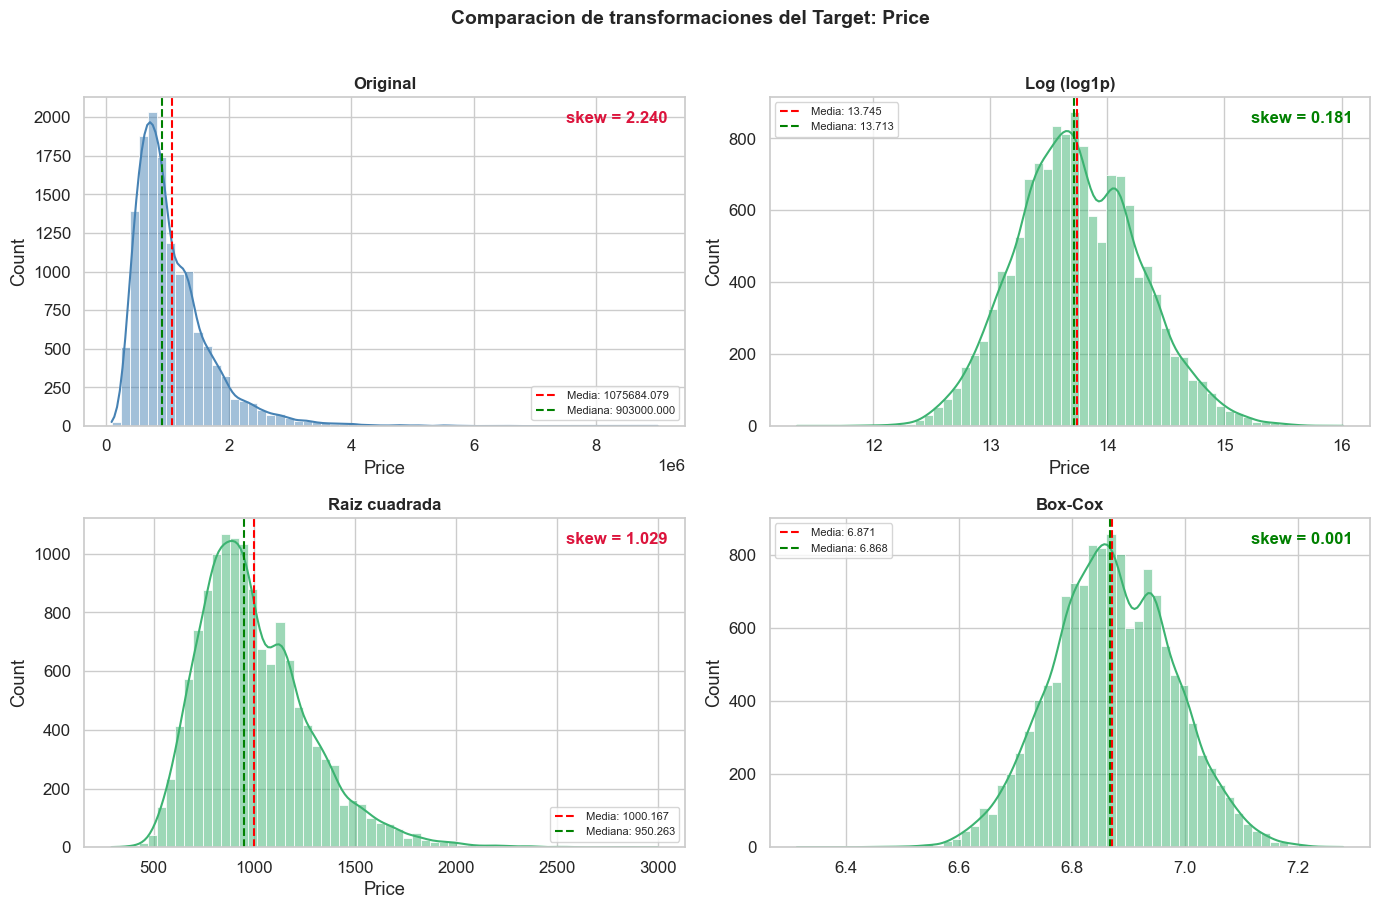

Elige la transformacion con menor |skewness| y mas parecida a una campana.


In [42]:
# ── 6b. Comparar transformaciones disponibles ────────────────────────────────
# Graficamos la distribucion original y tres transformaciones para decidir.
# Elegimos la que mas se parezca a una distribucion normal (campana simetrica).

target_limpio = target[target > 0]  # log requiere valores estrictamente positivos

transformaciones = {
    'Original': target_limpio,
    'Log (log1p)': np.log1p(target_limpio),
    'Raiz cuadrada': np.sqrt(target_limpio),
    'Box-Cox': pd.Series(stats.boxcox(target_limpio)[0], index=target_limpio.index)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (nombre, serie) in enumerate(transformaciones.items()):
    skew_val = serie.skew()
    color = 'steelblue' if nombre == 'Original' else 'mediumseagreen'
    sns.histplot(serie, ax=axes[i], kde=True, color=color, bins=60)
    axes[i].axvline(serie.mean(),   color='red',   ls='--', lw=1.5,
                    label=f'Media: {serie.mean():.3f}')
    axes[i].axvline(serie.median(), color='green', ls='--', lw=1.5,
                    label=f'Mediana: {serie.median():.3f}')
    color_skew = 'crimson' if abs(skew_val) > 1 else 'green'
    axes[i].annotate(f'skew = {skew_val:.3f}',
                     xy=(0.97, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=12, color=color_skew, fontweight='bold')
    axes[i].set_title(f'{nombre}', fontweight='bold', fontsize=12)
    axes[i].legend(fontsize=8)

fig.suptitle(f'Comparacion de transformaciones del Target: {TARGET_COL}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Elige la transformacion con menor |skewness| y mas parecida a una campana.')


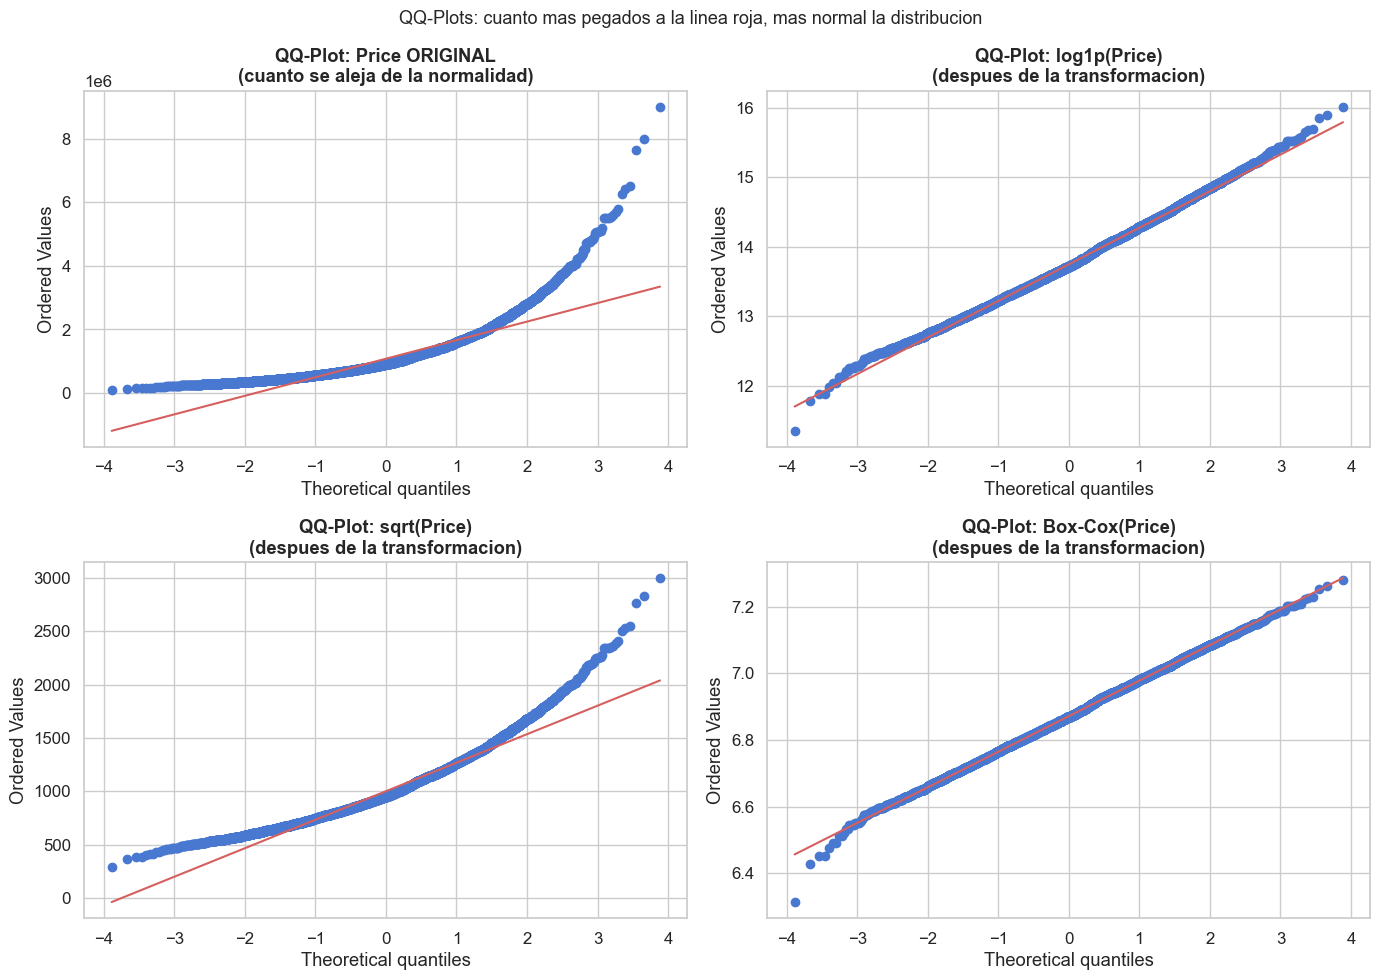

In [43]:
# ── 6c. QQ-Plot: confirmar normalidad despues de transformar ────────────────
# El QQ-Plot compara los cuantiles de tu dato vs los de una normal teorica.
# Si los puntos siguen la linea roja -> distribucion normal (ideal).
# Desviaciones en los extremos -> colas pesadas (outliers).

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Original
stats.probplot(target_limpio, dist='norm', plot=axes[0])
axes[0].set_title(f'QQ-Plot: {TARGET_COL} ORIGINAL\n(cuanto se aleja de la normalidad)',
                  fontweight='bold')

# Log-transformado
target_log = np.log1p(target_limpio)
stats.probplot(target_log, dist='norm', plot=axes[1])
axes[1].set_title(f'QQ-Plot: log1p({TARGET_COL})\n(despues de la transformacion)',
                  fontweight='bold')

# Raiz cuadrada
target_sqrt = np.sqrt(target_limpio)
stats.probplot(target_sqrt, dist='norm', plot=axes[2])
axes[2].set_title(f'QQ-Plot: sqrt({TARGET_COL})\n(despues de la transformacion)',
                  fontweight='bold')

# Box-Cox
target_boxcox = pd.Series(stats.boxcox(target_limpio)[0], index=target_limpio.index)
stats.probplot(target_boxcox, dist='norm', plot=axes[3])
axes[3].set_title(f'QQ-Plot: Box-Cox({TARGET_COL})\n(despues de la transformacion)',
                  fontweight='bold')


plt.suptitle('QQ-Plots: cuanto mas pegados a la linea roja, mas normal la distribucion',
             fontsize=13)
plt.tight_layout()
plt.show()



In [44]:
# DECISION POINT ── 6c. Aplicar transformacion elegida ────────────────────────────────
# DECISION POINT: aplica la transformacion elegida al dataset
# Descomenta la transformacion que quieras usar: log, raiz cuadrada o Box-Cox.

# OPCION 1: aplicando transformacion logaritmica
df[f'{TARGET_COL}_log'] = np.log1p(df[TARGET_COL])
TARGET_ANTERIOR = TARGET_COL  # Guardamos el nombre del target original por si lo necesitamos despues
df = df.drop(columns=[TARGET_ANTERIOR])  # Eliminamos la columna original si ya no la necesitamos
TARGET_COL = f'{TARGET_COL}_log'                    # Actualiza la referencia
print(f'Target transformado. Nueva columna: {TARGET_COL}')
print(f'Columna original eliminada: {TARGET_ANTERIOR}')
print(f'{TARGET_ANTERIOR} sigue en el dataset?: {TARGET_ANTERIOR in df.columns}')  # debe decir False

# OPCION 2: aplicando raiz cuadrada
# df[f'{TARGET_COL}_sqrt'] = np.sqrt(df[TARGET_COL])  # Crea columna nueva
# TARGET_ANTERIOR = TARGET_COL  # Guardamos el nombre del target original por si lo necesitamos despues
# df = df.drop(columns=[TARGET_ANTERIOR])  # Eliminamos la columna original si ya no la necesitamos
# TARGET_COL = f'{TARGET_COL}_sqrt'                    # Actualiza la referencia
# print(f'Target transformado. Nueva columna: {TARGET_COL}')
# print(f'Columna original eliminada: {TARGET_ANTERIOR}')
# print(f'{TARGET_ANTERIOR} sigue en el dataset?: {TARGET_ANTERIOR in df.columns}')  # debe decir False

# OPCION 3: aplicando Box-Cox (solo para valores positivos)
# df[f'{TARGET_COL}_boxcox'] = pd.Series(stats.boxcox(df[TARGET_COL][df[TARGET_COL] > 0])[0], index=df.index)
# TARGET_ANTERIOR = TARGET_COL  # Guardamos el nombre del target original por si lo necesitamos despues
# df = df.drop(columns=[TARGET_ANTERIOR])  # Eliminamos la columna original si ya no la necesitamos
# TARGET_COL = f'{TARGET_COL}_boxcox'                    # Actualiza la referencia  
# print(f'Target transformado. Nueva columna: {TARGET_COL}')
# print(f'Columna original eliminada: {TARGET_ANTERIOR}')
# print(f'{TARGET_ANTERIOR} sigue en el dataset?: {TARGET_ANTERIOR in df.columns}')  # debe decir False

Target transformado. Nueva columna: Price_log
Columna original eliminada: Price
Price sigue en el dataset?: False


---
## Paso 7 — Creacion de nuevas features (Feature Creation)

El dominio del problema es la fuente mas poderosa de features.
Nuevas variables construidas a partir de las existentes pueden capturar
relaciones que el modelo no descubriria solo con las variables originales.

**Tipos de features nuevas que puedes crear:**

| Tipo | Ejemplo | Cuando es util |
|---|---|---|
| Ratios / proporciones | `precio / m2` | Normaliza el efecto del tamano |
| Diferencias | `precio_actual - precio_anterior` | Captura cambios |
| Binarias / flags | `es_nuevo = (antiguedad < 5)` | Segmenta el dato |
| Interacciones | `habitaciones * banos` | Relacion entre dos variables |
| Extraccion de fechas | `mes`, `ano`, `dia_semana` | Estacionalidad |
| Agrupaciones | `ventas_promedio_por_region` | Contexto de grupo |
| Transformaciones | `log(area)`, `area^2` | Relaciones no lineales |

> **Regla:** Cada feature nueva debe tener una justificacion de negocio.
> No crees features al azar; crea las que tienen sentido en el contexto del problema.

---


In [45]:
# ── Listado de features ANTES de creacion de nuevos features ───────────────────
print(df.columns.to_list())

['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'CouncilArea_era_nulo', 'Price_log']


In [133]:
# DECISION POINT ── 7a. Features de interaccion entre variables numericas ───────────────────
# Las interacciones capturan el efecto combinado de dos variables.
# Ejemplo en inmobiliaria: habitaciones * banos es mejor indicador
# de 'comodidad total' que cada variable por separado.

# 'Adapta este bloque con las interacciones que tengan sentido en tu dataset.'
# 'Documenta cada feature con su justificacion de negocio.'

# DECISION POINT: define aqui las interacciones con sentido en tu problema
# Descomenta y adapta las lineas que apliquen a tu dataset:

# # Ejemplo de ratio (precio por unidad de superficie)
# if 'Landsize' in df.columns and 'Price' in df.columns:
#     df['precio_por_m2'] = df['Price'] / df['Landsize'].replace(0, np.nan)
#     print('Feature creada: precio_por_m2')


# print('\nEste nuevo feature puede ser un mejor predictor del valor que el precio o la superficie por separado.')
# print('Nos puede ayudar a identificar propiedades que son caras por su tamaño o que tienen un precio alto por metro cuadrado.')




In [46]:
# DECISION POINT ── 7b. Features binarias / flags ────────────────────────────────────────────
# Variables binarias (0/1) que indican si se cumple una condicion.
# Son extremadamente utiles para segmentar el dataset en grupos con
# comportamientos diferentes.

# DECISION POINT: define los flags que apliquen a tu problema

# Ejemplo: flag de propiedad nueva (antiguedad < 5 anos)
# if 'antiguedad' in df.columns:
#     df['es_nueva'] = (df['antiguedad'] < 5).astype(int)
#     print('Flag creado: es_nueva')

# Ejemplo: flag de precio premium (por encima del percentil 75)
# if TARGET_COL in df.columns:
#     p75 = df[TARGET_COL].quantile(0.75)
#     df['es_premium'] = (df[TARGET_COL] > p75).astype(int)
#     print(f'Flag creado: es_premium (umbral: {p75:.2f})')

df["+3_rooms"] = (df["Rooms"] >= 3).astype(int)
print('Flag creado: +3_rooms (1 si tiene 3 o mas habitaciones, 0 si tiene menos)')

print('\nEste flag nos permite identificar propiedades con mayor capacidad de alojamiento, que pueden ser mas atractivas para familias o grupos grandes.')


Flag creado: +3_rooms (1 si tiene 3 o mas habitaciones, 0 si tiene menos)

Este flag nos permite identificar propiedades con mayor capacidad de alojamiento, que pueden ser mas atractivas para familias o grupos grandes.


In [47]:
# DECISION POINT ── 7c. Extraccion de features desde columnas de fecha ──────────────────────
# Las fechas contienen multiples dimensiones temporales que el modelo
# no puede usar directamente: hay que descomponer la fecha en componentes.
# Cada componente puede capturar un patron diferente:
#   - Mes: estacionalidad (ej. mas ventas en diciembre)
#   - Dia de semana: tendencias semanales (ej. mas visitas los sabados)
#   - Ano: tendencia de largo plazo
#   - Trimestre: efectos trimestrales (ej. fin de ano fiscal)

# DECISION POINT: cambia 'nombre_columna_fecha' por tu columna de fecha real

if date_cols:
    for col_fecha in date_cols:
        # Asegurarse de que sea datetime
        df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')

        df[f'{col_fecha}_ano']         = df[col_fecha].dt.year
        df[f'{col_fecha}_mes']         = df[col_fecha].dt.month
        df[f'{col_fecha}_dia_semana']  = df[col_fecha].dt.dayofweek  # 0=lunes, 6=domingo
        df[f'{col_fecha}_trimestre']   = df[col_fecha].dt.quarter
        df[f'{col_fecha}_dia_del_ano'] = df[col_fecha].dt.dayofyear

        # Flag de fin de semana
        df[f'{col_fecha}_es_finde'] = (df[col_fecha].dt.dayofweek >= 5).astype(int)

        print(f'Features temporales creadas desde: {col_fecha}')
        print(f'   {col_fecha}_ano, {col_fecha}_mes, {col_fecha}_dia_semana, {col_fecha}_trimestre, {col_fecha}_dia_del_ano, {col_fecha}_es_finde')

else:
    print('No hay columnas de fecha detectadas.')
    print('Si tienes una, convierte primero: df["col"] = pd.to_datetime(df["col"])')


Features temporales creadas desde: Date
   Date_ano, Date_mes, Date_dia_semana, Date_trimestre, Date_dia_del_ano, Date_es_finde


In [48]:
# DECISION POINT:eliminar la columna original de fecha es opcional, dependiendo de si quieres conservarla para otros analisis o no
if date_cols:
    for col_fecha in date_cols:
        # Asegurarse de que sea datetime
        df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')
        df = df.drop(columns=[col_fecha])  # descomenta esta linea si quieres eliminar la columna original de fecha
    print(f'Columnas originales de fecha eliminadas: {date_cols}')
else:
    print('No hay columnas de fecha detectadas.')
    print('Si tienes una, convierte primero: df["col"] = pd.to_datetime(df["col"])')


Columnas originales de fecha eliminadas: ['Date']


In [136]:
# DECISION POINT ── 7d. Binning: convertir variables continuas en categorias ────────────────
# El binning divide una variable continua en grupos (bins).
# Util cuando la relacion con el target es escalonada en lugar de lineal.
# Ejemplo: la antiguedad de una propiedad tiene impactos diferentes
# en el rango 0-5 anos, 5-20 anos y mas de 20 anos.

# pd.cut():  bins de ancho fijo (basados en rangos de valores)
# pd.qcut(): bins de frecuencia fija (basados en cuantiles)

# DECISION POINT: adapta con tus columnas y rangos de negocio

# Ejemplo con pd.cut() (rangos con sentido de negocio)
# if 'antiguedad' in df.columns:
#     df['antiguedad_grupo'] = pd.cut(
#         df['antiguedad'],
#         bins=[0, 5, 15, 30, 100],
#         labels=['Nueva', 'Reciente', 'Establecida', 'Antigua'],
#         right=True, include_lowest=True
#     )
#     print('Feature binning creada: antiguedad_grupo')

# Ejemplo con pd.qcut() (cuartiles: 4 grupos iguales en frecuencia)
# if TARGET_COL in df.columns:
#     df['target_cuartil'] = pd.qcut(
#         df[TARGET_COL], q=4,
#         labels=['Q1_bajo', 'Q2', 'Q3', 'Q4_alto'],
#         duplicates='drop'
#     )
#     print('Feature binning creada: target_cuartil')



In [49]:
# ── Listado de features DESPUES de creacion de nuevos features ───────────────────
print(df.columns.to_list())

['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'CouncilArea_era_nulo', 'Price_log', '+3_rooms', 'Date_ano', 'Date_mes', 'Date_dia_semana', 'Date_trimestre', 'Date_dia_del_ano', 'Date_es_finde']


---
## Paso 8 — Codificacion de variables categoricas

Los algoritmos de ML trabajan con numeros. Las variables categoricas
(texto, etiquetas) deben convertirse a representaciones numericas.

**Tabla de decision: que codificacion usar?**

| Cardinalidad | Tipo | Codificacion recomendada | Razon |
|---|---|---|---|
| 2 categorias | Binaria | Label Encoding (0/1) | Simple y eficiente |
| 3-15 categorias | Nominal (sin orden) | One-Hot Encoding | Sin orden implicito |
| 3-15 categorias | Ordinal (con orden) | Ordinal Encoding | Preserva el orden |
| >15 categorias | Nominal | Target Encoding | Evita explosion de columnas |
| >15 categorias | ID / Nombre | Agrupar o descartar | Alta cardinalidad = ruido |

> **Nunca** apliques Label Encoding a variables nominales con 3+ categorias.
> Crea un orden artificial (Gato=1, Perro=2, Pez=3) que confunde al modelo.

---


In [50]:
# ── 8a. Diagnostico de variables categoricas ─────────────────────────────────
# Actualizamos cat_cols con el estado actual del dataframe
# (puede haber cambiado desde el paso 2 si se eliminaron columnas o se hizo OHE parcial)

cat_cols = df.select_dtypes(include='object').columns.tolist()

if cat_cols:
    print('=== DIAGNOSTICO DE VARIABLES CATEGORICAS ===')
    print(f'{"Columna":<25} {"Cardinalidad":>12} {"Tipo sugerido":<20} {"Top 3 valores"}')
    print('-' * 80)
    for col in cat_cols:
        n_unicos = df[col].nunique()
        top3 = df[col].value_counts().head(3).index.tolist()
        if n_unicos == 2:
            tipo = 'Binaria -> Label'
        elif n_unicos <= 15:
            tipo = 'Baja -> OHE / Ordinal'
        else:
            tipo = 'Alta -> Target Enc / Agrupar'
        print(f'{col:<25} {n_unicos:>12} {tipo:<20} {top3}')
    print('\nRecuerda: Si tienes que aplicar Target Encoding hazlo dentro del paso 3a de modelado para evitar leakage.')
else:
    print('No hay columnas categoricas en el dataset.')


=== DIAGNOSTICO DE VARIABLES CATEGORICAS ===
Columna                   Cardinalidad Tipo sugerido        Top 3 valores
--------------------------------------------------------------------------------
Suburb                             314 Alta -> Target Enc / Agrupar ['Reservoir', 'Richmond', 'Bentleigh East']
Address                          13378 Alta -> Target Enc / Agrupar ['5 Charles St', '13 Robinson St', '5 Margaret St']
Type                                 3 Baja -> OHE / Ordinal ['h', 'u', 't']
Method                               5 Baja -> OHE / Ordinal ['S', 'SP', 'PI']
SellerG                            268 Alta -> Target Enc / Agrupar ['Nelson', 'Jellis', 'hockingstuart']
CouncilArea                         34 Alta -> Target Enc / Agrupar ['Desconocido', 'Moreland', 'Boroondara']
Regionname                           8 Baja -> OHE / Ordinal ['Southern Metropolitan', 'Northern Metropolitan', 'Western Metropolitan']

Recuerda: Si tienes que aplicar Target Encoding hazlo dentr

In [51]:
# DECISION POINT ── 8b. One-Hot Encoding (OHE) para variables nominales ENTRE 3 y 15 categorias ──────────────────────
# OHE crea una columna binaria (0/1) por cada categoria unica.
# Ejemplo: 'color' con [rojo, azul, verde] -> 3 columnas: color_rojo, color_azul, color_verde
# drop='first': elimina la primera categoria para evitar multicolinealidad perfecta


# DECISION POINT: define las columnas nominales con baja cardinalidad (<= 15)
UMBRAL_MIN = 3
UMBRAL_MAX = 15

cols_ohe = [c for c in cat_cols if UMBRAL_MIN <= df[c].nunique() <= UMBRAL_MAX]  # Ajusta el umbral

if cols_ohe:
    print(f'Aplicando One-Hot Encoding a: {cols_ohe}')

    # Opcion 1: pd.get_dummies() (rapida para exploracion)
    df = pd.get_dummies(df, columns=cols_ohe, drop_first=True, dtype=int)

    nuevas_cols = [c for c in df.columns if any(c.startswith(base) for base in cols_ohe)]
    print(f'   Columnas generadas: {len(nuevas_cols)}')
    print(f'   Nuevas columnas: {nuevas_cols[:10]}...')  # Muestra solo las primeras 10
    print(f'   Shape del dataset: {df.shape}')
else:
    print('No hay columnas categoricas con cardinalidad <= 15 para OHE.')


Aplicando One-Hot Encoding a: ['Type', 'Method', 'Regionname']
   Columnas generadas: 13
   Nuevas columnas: ['Type_t', 'Type_u', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan']...
   Shape del dataset: (13580, 36)


In [140]:
# # DECISION POINT ── 8c. Ordinal Encoding para variables con orden natural ────────────────────
# # Asigna un numero entero a cada categoria RESPETANDO el orden logico.
# # Ejemplo: ['Malo', 'Regular', 'Bueno', 'Excelente'] -> [0, 1, 2, 3]
# # OJO: si usas LabelEncoder o OHE aqui, perderias el orden y confundirias al modelo.

# # DECISION POINT: define las columnas ordinales y su orden correcto

# # Ejemplo de columna ordinal:
# cols_ordinales = {
#     'calidad_construccion': ['Baja', 'Media', 'Alta', 'Premium'],
#     'nivel_educativo': ['Bachiller', 'Tecnico', 'Profesional', 'Posgrado'],
#     'riesgo_credito': ['Bajo', 'Medio', 'Alto'],
# }

# for col, orden in cols_ordinales.items():
#     if col in df.columns:
#         oe = OrdinalEncoder(categories=[orden], handle_unknown='use_encoded_value', unknown_value=-1)
#         df[col] = oe.fit_transform(df[[col]])
#         print(f'Ordinal Encoding aplicado a: {col}')
#         print(f'   Orden: {orden} -> {list(range(len(orden)))}')


In [52]:
# # DECISION POINT ── 8d. Eliminar columnas de alta cardinalidad sin valor predictivo ───────────
# # Las columnas con cientos de categorias unicas (Address, SellerG, etc.)
# # no aportan informacion util al modelo: demasiadas categorias con pocos
# # registros cada una generan ruido en lugar de patrones aprendibles.
# # Se eliminan aqui antes del split para que no entren al Pipeline.

cols_alta_cardinalidad = ['Address', 'SellerG', 'Suburb', 'CouncilArea']  # ajusta con tu diagnostico

cols_a_eliminar = [c for c in cols_alta_cardinalidad if c in df.columns]

if cols_a_eliminar:
    df = df.drop(columns=cols_a_eliminar)
    print(f'Columnas eliminadas por alta cardinalidad ({len(cols_a_eliminar)}):')
    for col in cols_a_eliminar:
        print(f'   {col}')
    print(f'\nShape del dataset: {df.shape}')
else:
    print('No habia columnas de alta cardinalidad pendientes.')

Columnas eliminadas por alta cardinalidad (4):
   Address
   SellerG
   Suburb
   CouncilArea

Shape del dataset: (13580, 32)


---
## Paso 9 — Escalado y Normalizacion

Los algoritmos que calculan distancias o usan gradientes (Regresion Lineal, KNN,
SVM, Redes Neuronales) son sensibles a la escala de las variables.

Si `area` va de 20 a 500 y `habitaciones` va de 1 a 6, el modelo tratara a
`area` como mas importante solo por su magnitud, no por su informacion real.

**Tabla de decision: que escalador usar?**

| Escalador | Formula | Cuando usarlo | No usar cuando... |
|---|---|---|---|
| **StandardScaler** | `(x - media) / std` | Default. Distribuciones aprox. normales | Hay outliers extremos |
| **MinMaxScaler** | `(x - min) / (max - min)` | Cuando el rango importa. Redes neuronales | Hay outliers extremos |
| **RobustScaler** | `(x - mediana) / IQR` | Cuando hay outliers importantes | - |
| **PowerTransformer** | Yeo-Johnson / Box-Cox | Distribucion muy sesgada | - |

> **Regla:** Arboles de decision (Random Forest, XGBoost) NO necesitan escalado.
> El escalado es obligatorio para modelos lineales, KNN y redes neuronales.

---


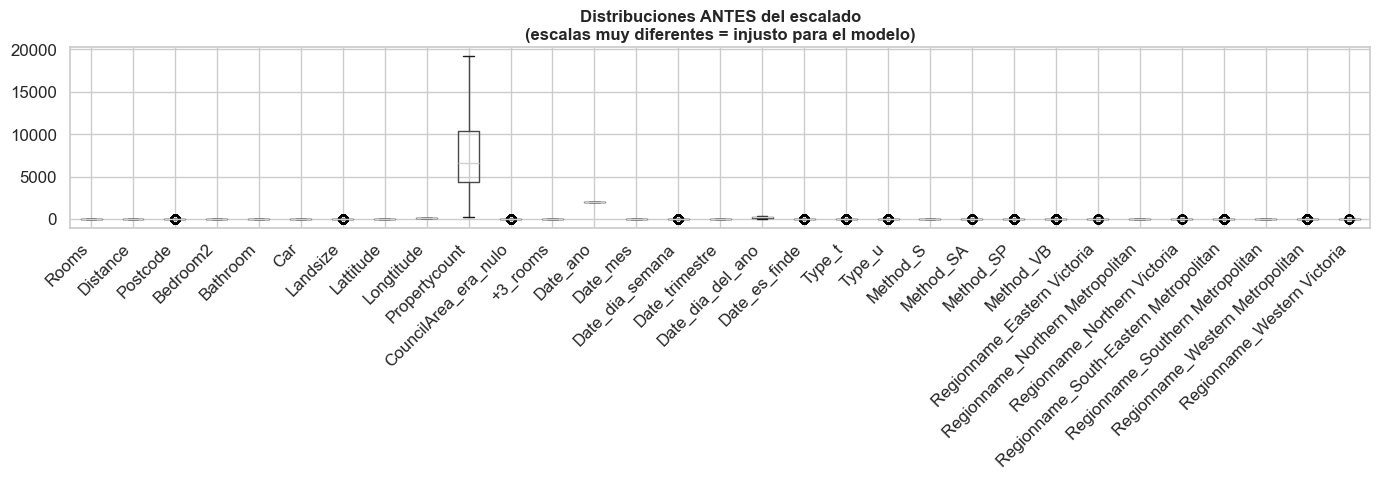

Rango de cada variable ANTES del escalado:


,min,max,mean,std
Rooms,1.00,4.50,2.90,0.88
Distance,0.00,23.35,9.91,5.06
Postcode,8.01,8.29,8.04,0.03
Bedroom2,0.50,4.50,2.88,0.88
Bathroom,0.00,3.50,1.53,0.65
Car,0.00,3.50,1.57,0.83
Landsize,0.00,12.98,5.21,2.24
Lattitude,-38.01,-37.61,-37.81,0.08
Longtitude,144.74,145.25,145.00,0.10
Propertycount,249.00,19257.50,7391.17,4186.11


In [53]:
# ── 9a. Visualizar distribuciones antes del escalado ────────────────────────
# Graficamos los rangos actuales de las variables numericas para motivar el escalado.
# Si las cajas estan en escalas muy diferentes, el modelo sera injusto con las pequenas.

num_features = [c for c in df.select_dtypes(include='number').columns
                if c != TARGET_COL]

if num_features:
    # Boxplots sin escalar
    fig, ax = plt.subplots(figsize=(14, 5))
    df[num_features].boxplot(ax=ax, vert=True)
    ax.set_xticklabels(num_features, rotation=45, ha='right')
    ax.set_title('Distribuciones ANTES del escalado\n'
                 '(escalas muy diferentes = injusto para el modelo)',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('Rango de cada variable ANTES del escalado:')
    rangos = df[num_features].agg(['min', 'max', 'mean', 'std']).T
    display(rangos.style.background_gradient(subset=['std'], cmap='Oranges').format(precision=2))


Visualizando escaladores solo sobre columnas continuas (14, excluyendo binarias y flags):


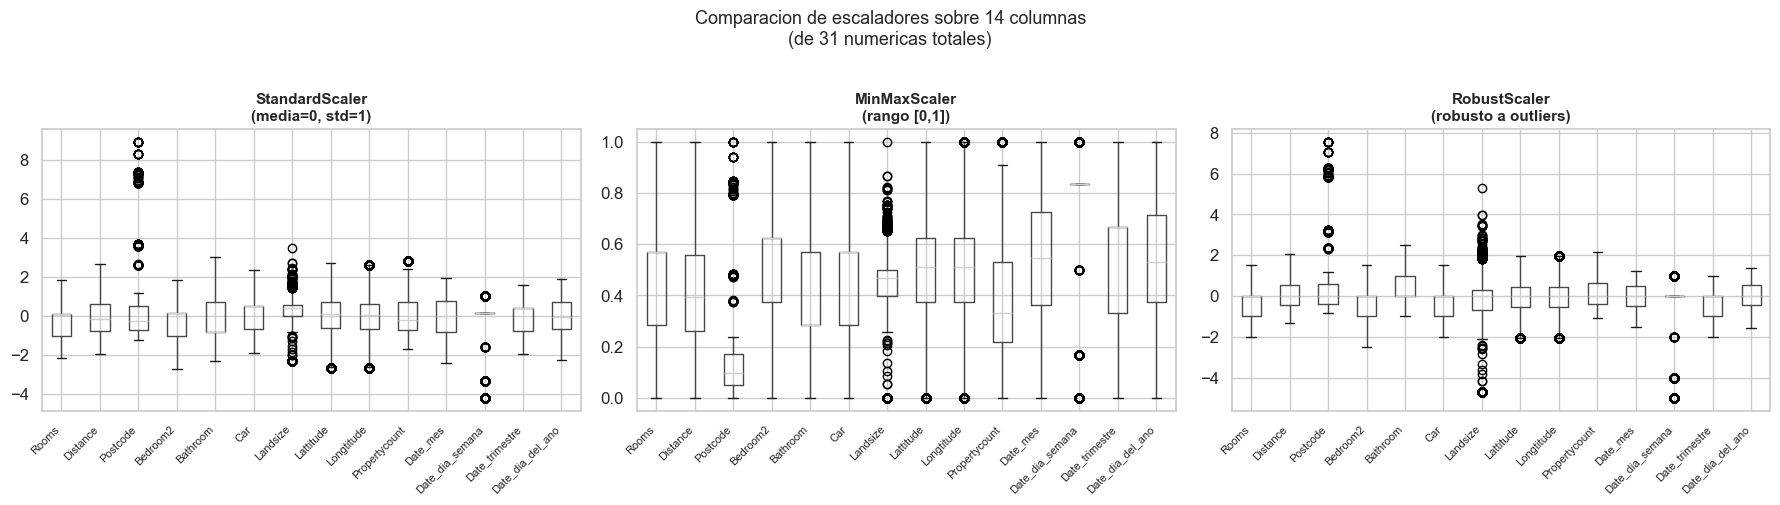

Columnas que NO se escalaran (17):
   CouncilArea_era_nulo           nunique=2
   +3_rooms                       nunique=2
   Date_ano                       nunique=2
   Date_es_finde                  nunique=2
   Type_t                         nunique=2
   Type_u                         nunique=2
   Method_S                       nunique=2
   Method_SA                      nunique=2
   Method_SP                      nunique=2
   Method_VB                      nunique=2
   Regionname_Eastern Victoria    nunique=2
   Regionname_Northern Metropolitan nunique=2
   Regionname_Northern Victoria   nunique=2
   Regionname_South-Eastern Metropolitan nunique=2
   Regionname_Southern Metropolitan nunique=2
   Regionname_Western Metropolitan nunique=2
   Regionname_Western Victoria    nunique=2

Elige el escalador que mejor se adapte a tus datos y tipo de modelo.


In [54]:
# DECISION POINT ── 9b. Comparar escaladores con seleccion dinamica de columnas ──────────────
# Puedes comparar el efecto del escalado sobre TODAS las columnas numericas
# o solo sobre un subconjunto especifico.
# Modifica cols_a_visualizar segun lo que quieras analizar.

# OPCION A: visualizar todas las columnas numericas
# cols_a_visualizar = num_features
# print(f'Visualizando escaladores sobre TODAS las columnas numericas ({len(cols_a_visualizar)}):')

# OPCION B: visualizar solo las columnas continuas (excluir binarias y flags)
# Las columnas binarias (0/1) y los indicadores de nulos no necesitan escalado.
cols_binarias = [c for c in num_features if df[c].nunique() <= 2]
cols_a_visualizar = [c for c in num_features if c not in cols_binarias]
print(f'Visualizando escaladores solo sobre columnas continuas ({len(cols_a_visualizar)}, excluyendo binarias y flags):')

# OPCION C: definir manualmente las columnas que quieres escalar
# cols_a_visualizar = ['Rooms', 'Distance', 'Landsize', 'BuildingArea']
# print(f'Visualizando escaladores solo sobre columnas seleccionadas ({len(cols_a_visualizar)}): {cols_a_visualizar}')

if cols_a_visualizar:
    df_esc_std    = pd.DataFrame(
        StandardScaler().fit_transform(df[cols_a_visualizar]),
        columns=cols_a_visualizar)
    df_esc_minmax = pd.DataFrame(
        MinMaxScaler().fit_transform(df[cols_a_visualizar]),
        columns=cols_a_visualizar)
    df_esc_robust = pd.DataFrame(
        RobustScaler().fit_transform(df[cols_a_visualizar]),
        columns=cols_a_visualizar)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (nombre, df_s) in zip(axes, [
        ('StandardScaler\n(media=0, std=1)',      df_esc_std),
        ('MinMaxScaler\n(rango [0,1])',            df_esc_minmax),
        ('RobustScaler\n(robusto a outliers)',     df_esc_robust)
    ]):
        df_s.boxplot(ax=ax)
        ax.set_xticklabels(df_s.columns, rotation=45, ha='right', fontsize=8)
        ax.set_title(nombre, fontweight='bold', fontsize=11)

    fig.suptitle(
        f'Comparacion de escaladores sobre {len(cols_a_visualizar)} columnas\n'
        f'(de {len(num_features)} numericas totales)',
        fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Mostrar las columnas que quedan FUERA del escalado
    cols_sin_escalar = [c for c in num_features if c not in cols_a_visualizar]
    if cols_sin_escalar:
        print(f'Columnas que NO se escalaran ({len(cols_sin_escalar)}):')
        for col in cols_sin_escalar:
            print(f'   {col:<30} nunique={df[col].nunique()}')
    print(f'\nElige el escalador que mejor se adapte a tus datos y tipo de modelo.')

In [55]:
# DECISION POINT ── 9c. Registrar el escalador elegido ───────────────────────────────────────
# elige el escalador basandote en el grafico anterior.
# El escalado real se aplica DENTRO del Pipeline (Notebook de Modelado)
# para evitar Data Leakage. Aqui solo registramos la decision.
#
# IMPORTANTE: NO aplicar fit_transform al df aqui.
# El escalador aprende sus parametros SOLO del train dentro del Pipeline.

cols_binarias   = [c for c in num_features if df[c].nunique() <= 2]
cols_a_escalar  = [c for c in cols_a_visualizar if c not in cols_binarias] # Ajusta si no quieres escalar todas

# Elige el escalador: descomenta el que corresponda
# escalador = StandardScaler()   # Distribucion aprox. normal, sin outliers fuertes
# escalador = MinMaxScaler()      # Rango acotado, sin outliers
escalador = RobustScaler()      # Con outliers (como este dataset de Melbourne)

print(f'Escalador elegido  : {type(escalador).__name__}')
print(f'Columnas a escalar : {len(cols_a_escalar)} de {len(num_features)} numericas')
print(f'Columnas excluidas : {cols_binarias}')
print('-> Este subconjunto se pasa al Pipeline del Notebook de Modelado.')


Escalador elegido  : RobustScaler
Columnas a escalar : 14 de 31 numericas
Columnas excluidas : ['CouncilArea_era_nulo', '+3_rooms', 'Date_ano', 'Date_es_finde', 'Type_t', 'Type_u', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan', 'Regionname_Western Victoria']
-> Este subconjunto se pasa al Pipeline del Notebook de Modelado.


---
## Paso 10 — Seleccion de Features PCA y Reduccion de Dimensionalidad

Mas features no siempre es mejor. Variables redundantes o irrelevantes pueden:
- Aumentar el ruido y degradar el modelo (curse of dimensionality)
- Aumentar el tiempo de entrenamiento
- Dificultar la interpretacion

**Metodos de seleccion:**

| Metodo | Tipo | Ventaja | Limitacion |
|---|---|---|---|
| Correlacion con target | Filtro | Rapido, intuitivo | Solo relaciones lineales |
| VarianceThreshold | Filtro | Elimina constantes | No considera el target |
| SelectKBest (F-test) | Filtro | Test estadistico formal | Solo relaciones lineales |
| Mutual Information | Filtro | Captura no linealidad | Mas lento |
| RFE con modelo | Wrapper | Optimo para el modelo elegido | Lento, dependiente del modelo |
| Importancia de arboles | Embedded | Robusto, rapido | Depende del modelo |

---


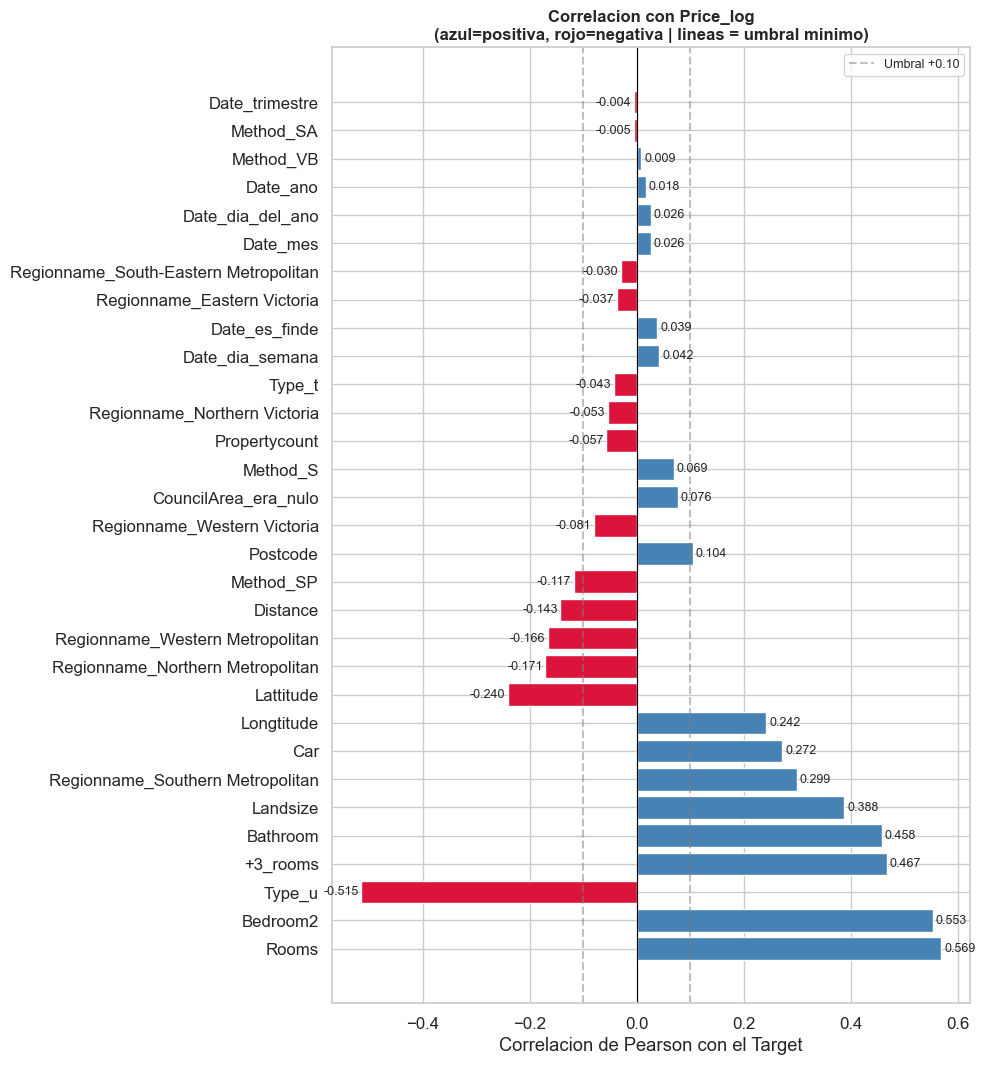

Top 10 mas correlacionadas con Price_log:
Rooms                               0.5691
Bedroom2                            0.5525
Type_u                             -0.5148
+3_rooms                            0.4671
Bathroom                            0.4579
Landsize                            0.3880
Regionname_Southern Metropolitan    0.2987
Car                                 0.2723
Longtitude                          0.2422
Lattitude                          -0.2402


In [56]:
# ── 10a. Correlacion con el target (seleccion basica) ────────────────────────
# El coeficiente de Pearson mide la relacion LINEAL entre cada feature y el target.
# Features con |r| < 0.05 rara vez aportan informacion util a modelos lineales.
# Nota: no descarta relaciones no lineales, solo las lineales.

num_df = df.select_dtypes(include='number')

if TARGET_COL in num_df.columns:
    corr_target = num_df.corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(corr_target) * 0.35)))

    colores = ['crimson' if v < 0 else 'steelblue' for v in corr_target]
    bars = ax.barh(corr_target.index, corr_target.values, color=colores, edgecolor='white')

    ax.axvline(0.1,  color='gray', ls='--', alpha=0.5, label='Umbral +0.10')
    ax.axvline(-0.1, color='gray', ls='--', alpha=0.5)
    ax.axvline(0,    color='black', lw=0.8)

    for bar, val in zip(bars, corr_target.values):
        ax.text(val + (0.005 if val >= 0 else -0.005),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9,
                ha='left' if val >= 0 else 'right')

    ax.set_xlabel('Correlacion de Pearson con el Target')
    ax.set_title(f'Correlacion con {TARGET_COL}\n'
                 '(azul=positiva, rojo=negativa | lineas = umbral minimo)',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'Top 10 mas correlacionadas con {TARGET_COL}:')
    print(corr_target.head(10).to_string())
else:
    print(f'El TARGET_COL ({TARGET_COL}) no es numerico o no esta en el dataset.')


In [57]:
# ── 10b. Detectar features con varianza casi nula (quasi-constantes) ─────────
# Una variable con varianza cercana a cero tiene casi el mismo valor en
# todas las filas -> no aporta informacion al modelo y solo agrega ruido.

num_features_actual = [c for c in df.select_dtypes(include='number').columns
                        if c != TARGET_COL]

if num_features_actual:
    vt = VarianceThreshold(threshold=0.01)
    vt.fit(df[num_features_actual])
    features_eliminadas = [f for f, s in zip(num_features_actual, vt.get_support()) if not s]

    if features_eliminadas:
        print(f'Features con varianza casi nula ({len(features_eliminadas)}):')
        column_names = df[features_eliminadas].columns
        for col in features_eliminadas:
            print(f'   {col:<30} varianza = {df[col].var():.6f}')

        print(f'\nEstas features pueden ser eliminadas sin perder informacion util.')
        print(f'\ncolumnas: {list(column_names)}')
        print('\n-> Revisa si estas features tienen sentido de negocio antes de eliminarlas.')
    else:
        print('No se detectaron features con varianza casi nula.')

Features con varianza casi nula (7):
   Postcode                       varianza = 0.000768
   Lattitude                      varianza = 0.005661
   Longtitude                     varianza = 0.009617
   Method_SA                      varianza = 0.006729
   Regionname_Eastern Victoria    varianza = 0.003888
   Regionname_Northern Victoria   varianza = 0.003010
   Regionname_Western Victoria    varianza = 0.002351

Estas features pueden ser eliminadas sin perder informacion util.

columnas: ['Postcode', 'Lattitude', 'Longtitude', 'Method_SA', 'Regionname_Eastern Victoria', 'Regionname_Northern Victoria', 'Regionname_Western Victoria']

-> Revisa si estas features tienen sentido de negocio antes de eliminarlas.


In [58]:
# DECISION POINT ── 10b. Eliminar features con varianza casi nula (quasi-constantes) ─────────
# Una variable con varianza cercana a cero tiene casi el mismo valor en
# todas las filas -> no aporta informacion al modelo y solo agrega ruido.

if features_eliminadas:

    # DECISION POINT: descomenta para eliminar
    features_para_eliminar = ['Postcode', 'Lattitude', 'Longtitude', 'Method_SA', 'Regionname_Eastern Victoria', 'Regionname_Northern Victoria', 'Regionname_Western Victoria']  # Ajusta si quieres conservar alguna
    df = df.drop(columns=features_para_eliminar)
    print(f'   Eliminadas: {features_para_eliminar}')
else:
    print('Ninguna feature fue eliminada porque no tiene varianza quasi-nula. Todas conservan informacion.')


   Eliminadas: ['Postcode', 'Lattitude', 'Longtitude', 'Method_SA', 'Regionname_Eastern Victoria', 'Regionname_Northern Victoria', 'Regionname_Western Victoria']


In [59]:
# ── 10c. Detectar multicolinealidad entre features ───────────────────────────
# Dos features muy correlacionadas entre si (>0.85) aportan informacion redundante.
# En modelos lineales esto causa coeficientes inestables e interpretacion problematica.
# En arboles el impacto es menor, pero igual genera redundancia.
# Para cada par multicolineal, eliminamos la que menos aporta al target.

UMBRAL_MULTI = 0.85

num_features_actual = [c for c in df.select_dtypes(include='number').columns
                        if c != TARGET_COL]

if len(num_features_actual) > 1:
    corr_matrix = df[num_features_actual].corr().abs()

    # Extraer solo el triangulo superior (evitar duplicados y la diagonal)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pares_multi = [
        (c1, c2, upper.loc[c1, c2])
        for c1 in upper.columns
        for c2 in upper.columns
        if pd.notna(upper.loc[c1, c2]) and upper.loc[c1, c2] > UMBRAL_MULTI
    ]

    if pares_multi:
        print(f'Pares con correlacion > {UMBRAL_MULTI} (posible multicolinealidad):')
        for c1, c2, r in sorted(pares_multi, key=lambda x: -x[2]):
            print(f'   {c1:<25} <->  {c2:<25}  r = {r:.3f}')
        print('\n-> Para cada par, eliminar la que tenga MENOR correlacion con el target.')

    else:
        print(f'Sin multicolinealidad critica (ninguna correlacion > {UMBRAL_MULTI}).')


if 'pares_multi' not in dir() or not pares_multi:
    print('Sin pares multicolineales detectados. Nada que eliminar.')
else:
    columnas_a_eliminar = set()
    for c1, c2, r in pares_multi:
        corr_c1 = abs(df[c1].corr(df[TARGET_COL]))
        corr_c2 = abs(df[c2].corr(df[TARGET_COL]))
        if corr_c1 < corr_c2:
            columnas_a_eliminar.add(c1)
            print(f'   Columna a eliminar {c1} (r={corr_c1:.3f}) en favor de {c2} (r={corr_c2:.3f})')
        else:
            columnas_a_eliminar.add(c2)
            print(f'   Columna a eliminar {c2} (r={corr_c2:.3f}) en favor de {c1} (r={corr_c1:.3f})')
    if columnas_a_eliminar:
        print(f'\nColumnas a eliminar por multicolinealidad: {list(columnas_a_eliminar)}')
        print('Revisa cada una antes de eliminar.')



Pares con correlacion > 0.85 (posible multicolinealidad):
   Date_mes                  <->  Date_dia_del_ano           r = 0.994
   Date_dia_semana           <->  Date_es_finde              r = 0.963
   Rooms                     <->  Bedroom2                   r = 0.959
   Date_trimestre            <->  Date_dia_del_ano           r = 0.953
   Date_mes                  <->  Date_trimestre             r = 0.953

-> Para cada par, eliminar la que tenga MENOR correlacion con el target.
   Columna a eliminar Bedroom2 (r=0.553) en favor de Rooms (r=0.569)
   Columna a eliminar Date_trimestre (r=0.004) en favor de Date_mes (r=0.026)
   Columna a eliminar Date_dia_del_ano (r=0.026) en favor de Date_mes (r=0.026)
   Columna a eliminar Date_es_finde (r=0.039) en favor de Date_dia_semana (r=0.042)
   Columna a eliminar Date_trimestre (r=0.004) en favor de Date_dia_del_ano (r=0.026)

Columnas a eliminar por multicolinealidad: ['Date_es_finde', 'Bedroom2', 'Date_dia_del_ano', 'Date_trimestre']
Revi

In [60]:
# DECISION POINT ── 10d. Eliminar features correlacionadas con baja correlacion con target ────
# DECISION POINT: revisa los pares del paso anterior antes de ejecutar.

# columnas_para_eliminar = list(columnas_a_eliminar)  # Ajusta con tu decision despues de revisar los pares multicolineales
columnas_para_eliminar = ['Date_es_finde', 'Bedroom2', 'Date_dia_del_ano', 'Date_trimestre']  # Ajusta con tu decision despues de revisar los pares multicolineales

if columnas_para_eliminar:
    # DECISION POINT: descomenta para eliminar
    features_para_eliminar = list(columnas_para_eliminar)
    for col in features_para_eliminar:
        print(f'   Eliminando {col} por baja correlacion con el target y alta correlacion con otra feature.')
        df = df.drop(columns=col if col in df.columns else []) # Elimina solo si la columna sigue existiendo (puede haber sido eliminada antes)
    print(f'\nColumnas eliminadas: {features_para_eliminar}')
        


   Eliminando Date_es_finde por baja correlacion con el target y alta correlacion con otra feature.
   Eliminando Bedroom2 por baja correlacion con el target y alta correlacion con otra feature.
   Eliminando Date_dia_del_ano por baja correlacion con el target y alta correlacion con otra feature.
   Eliminando Date_trimestre por baja correlacion con el target y alta correlacion con otra feature.

Columnas eliminadas: ['Date_es_finde', 'Bedroom2', 'Date_dia_del_ano', 'Date_trimestre']


---
### Por que usamos SelectKBest?

**El problema que resuelve:** Cuando tienes muchas columnas, no todas son utiles.
Meter todas al modelo causa overfitting, mayor tiempo de entrenamiento y peor interpretabilidad.

**Score F (`f_regression` / `f_classif`)**
- Mide si la variacion de una feature explica la del target
- Asume relacion **lineal** entre feature y target
- p-valor < 0.05: la relacion no es producto del azar

**Informacion Mutua (`mutual_info_regression`)**
- Mide dependencia estadistica **sin asumir linealidad**
- Captura relaciones curvas, interacciones y patrones complejos
- Score de 0 = feature independiente del target (inutil)

**Por que usar los dos juntos:**

| Situacion | Score F | Info. Mutua |
|---|---|---|
| Relacion lineal fuerte | Alto | Alto |
| Relacion no lineal | Bajo | Alto |
| Feature de ruido | Bajo | Bajo |

Si una feature tiene Score F bajo pero Info. Mutua alta, la relacion existe
pero es no lineal. El test F solo te la habria descartado por error.

---


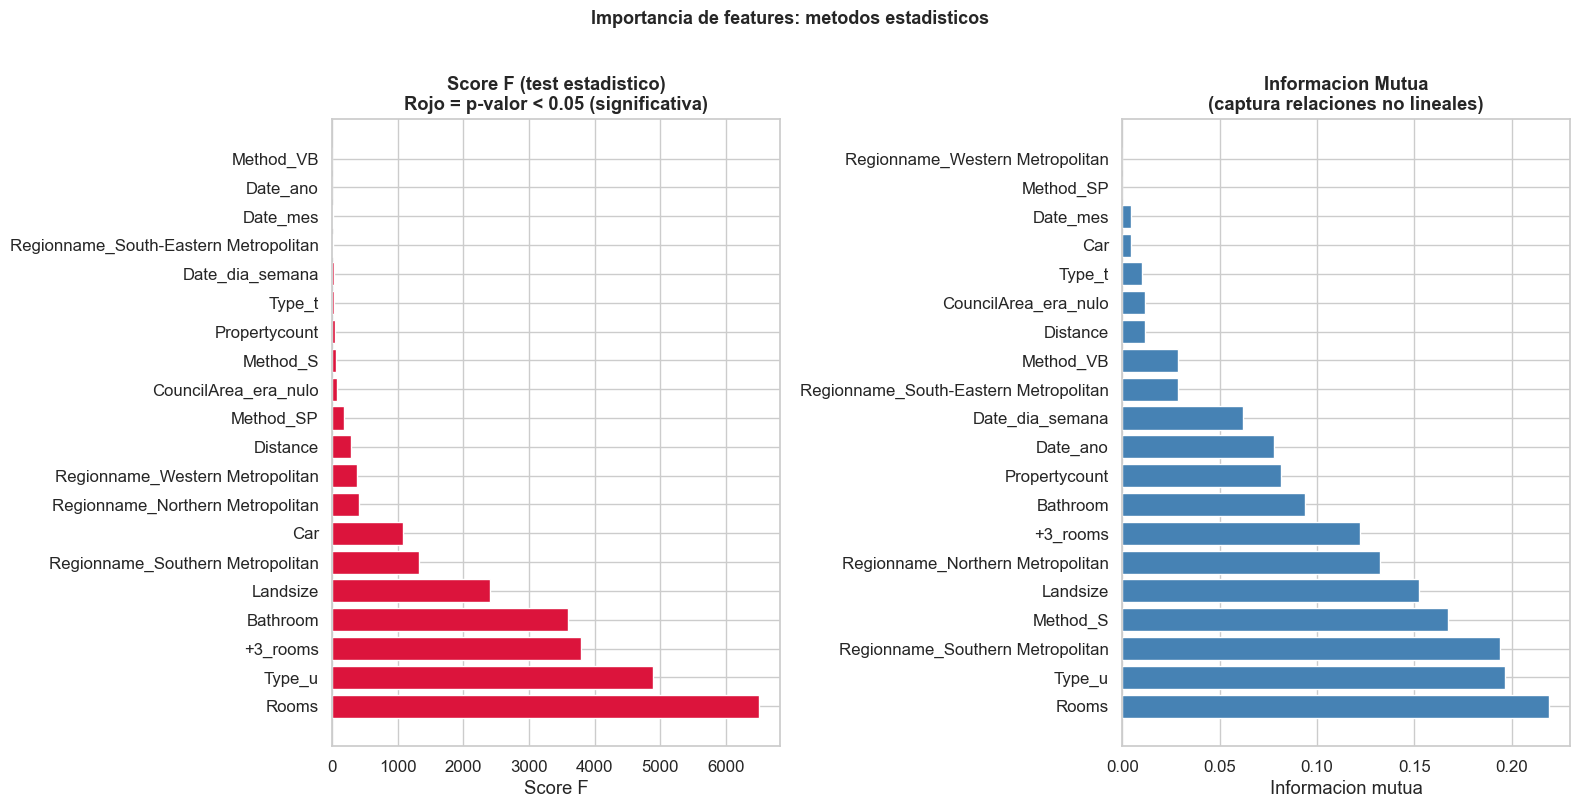


Features con p-valor < 0.05 (significativas estadisticamente):


,Feature,Score F,p-valor,Info. Mutua
0,Rooms,6505.0597,0.0000,0.2191
12,Type_u,4895.6958,0.0000,0.1967
7,+3_rooms,3789.7938,0.0000,0.1221
2,Bathroom,3601.2636,0.0000,0.0940
4,Landsize,2405.8478,0.0000,0.1521
18,Regionname_Southern Metropolitan,1329.9454,0.0000,0.1942
3,Car,1087.1106,0.0000,0.0048
16,Regionname_Northern Metropolitan,406.6277,0.0000,0.1321
19,Regionname_Western Metropolitan,387.1372,0.0000,0.0000
1,Distance,282.1455,0.0000,0.0117



Features con mayor informacion mutua (relaciones no lineales):


,Feature,Score F,p-valor,Info. Mutua
0,Rooms,6505.0597,0.0000,0.2191
12,Type_u,4895.6958,0.0000,0.1967
18,Regionname_Southern Metropolitan,1329.9454,0.0000,0.1942
13,Method_S,64.7953,0.0000,0.1672
4,Landsize,2405.8478,0.0000,0.1521
16,Regionname_Northern Metropolitan,406.6277,0.0000,0.1321
7,+3_rooms,3789.7938,0.0000,0.1221
2,Bathroom,3601.2636,0.0000,0.0940
5,Propertycount,43.6404,0.0000,0.0815
8,Date_ano,4.3115,0.0379,0.0781


In [61]:
# ── 10d. SelectKBest: seleccion estadistica formal ───────────────────────────
# SelectKBest aplica un test estadistico a cada feature y selecciona las K mejores.
# f_regression: test F (ANOVA) para problemas de REGRESION
# f_classif:    test F para problemas de CLASIFICACION
# mutual_info_regression: informacion mutua (captura relaciones NO lineales)

num_features_actual = [c for c in df.select_dtypes(include='number').columns
                        if c != TARGET_COL]

if num_features_actual and TARGET_COL in df.columns:
    X_sel = df[num_features_actual].fillna(0)  # SelectKBest no tolera nulos
    y_sel = df[TARGET_COL].fillna(df[TARGET_COL].median())

    # Test F para regresion (cambia a f_classif si es clasificacion)
    selector = SelectKBest(score_func=f_regression, k='all')
    selector.fit(X_sel, y_sel)

    importancias_f = pd.DataFrame({
        'Feature': num_features_actual,
        'Score F': selector.scores_,
        'p-valor': selector.pvalues_
    }).sort_values('Score F', ascending=False)

    # Informacion mutua (no lineal)
    from sklearn.feature_selection import mutual_info_regression
    mi_scores = mutual_info_regression(X_sel, y_sel, random_state=42)
    importancias_f['Info. Mutua'] = mi_scores

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(num_features_actual)*0.4)))

    # Score F
    colores_f = ['crimson' if p < 0.05 else 'lightgray'
                 for p in importancias_f['p-valor']]
    axes[0].barh(importancias_f['Feature'], importancias_f['Score F'],
                 color=colores_f, edgecolor='white')
    axes[0].set_title('Score F (test estadistico)\nRojo = p-valor < 0.05 (significativa)',
                       fontweight='bold')
    axes[0].set_xlabel('Score F')

    # Info mutua
    imp_mi = importancias_f.sort_values('Info. Mutua', ascending=False)
    axes[1].barh(imp_mi['Feature'], imp_mi['Info. Mutua'],
                 color='steelblue', edgecolor='white')
    axes[1].set_title('Informacion Mutua\n(captura relaciones no lineales)',
                       fontweight='bold')
    axes[1].set_xlabel('Informacion mutua')

    plt.suptitle('Importancia de features: metodos estadisticos',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print('\nFeatures con p-valor < 0.05 (significativas estadisticamente):')
    sig = importancias_f[importancias_f['p-valor'] < 0.05]
    display(sig.style.background_gradient(subset=['Score F'], cmap='Blues').format(precision=4))

    print('\nFeatures con mayor informacion mutua (relaciones no lineales):')
    mi_top = importancias_f.sort_values('Info. Mutua', ascending=False).head(10)
    display(mi_top.style.background_gradient(subset=['Info. Mutua'], cmap='Oranges').format(precision=4))
else:
    print('No hay features numericas o el TARGET_COL no esta en el dataset para aplicar SelectKBest.')


In [62]:
# ── 10e. Comparación de features a conservar solo si el modelo está sobreajustando o entrenando muy lento 
# Primero revisa cuantas features pasarian con cada criterio
print('Simulacion de criterios de seleccion:')
print(f'   p-valor < 0.05        : {(importancias_f["p-valor"] < 0.05).sum()} features')
print(f'   Info. Mutua > 0.01    : {(importancias_f["Info. Mutua"] > 0.01).sum()} features')
print(f'   Combinado (OR)        : {((importancias_f["p-valor"] < 0.05) | (importancias_f["Info. Mutua"] > 0.01)).sum()} features')
print(f'   Total actual          : {len(importancias_f)} features')
print('Primero entrena el modelo con todas las features en el Notebook de Modelado, revisa el R² en el Notebook de Evaluación, ' \
'y solo si el modelo está sobreajustando o entrenando muy lento vuelves al paso 10e y activas el filtro.')

Simulacion de criterios de seleccion:
   p-valor < 0.05        : 19 features
   Info. Mutua > 0.01    : 16 features
   Combinado (OR)        : 20 features
   Total actual          : 20 features
Primero entrena el modelo con todas las features en el Notebook de Modelado, revisa el R² en el Notebook de Evaluación, y solo si el modelo está sobreajustando o entrenando muy lento vuelves al paso 10e y activas el filtro.


In [152]:
# DECISION POINT ── 10e. filtrar y elegir features a conservar solo si el modelo está sobreajustando o entrenando muy lento 
# Basandote en los graficos del paso 10d, elige el criterio de seleccion.
# Este filtro reduce el df antes del split del paso 11.

# DECISION POINT: elige UNO de estos criterios y descomenta

# Criterio 1: solo features estadisticamente significativas (mas conservador)
# features_finales = importancias_f[importancias_f['p-valor'] < 0.05]['Feature'].tolist()

# Criterio 2: features con relacion lineal O no lineal con el target
# features_finales = importancias_f[
#     (importancias_f['p-valor'] < 0.05) |
#     (importancias_f['Info. Mutua'] > 0.01)
# ]['Feature'].tolist()

# Criterio 3: top K features por Score F (numero fijo)
# K = 10
# features_finales = importancias_f.head(K)['Feature'].tolist()

# ── Aplicar el filtro ─────────────────────────────────────────────────────────
# Descomenta las siguientes lineas cuando hayas elegido el criterio de arriba

# cols_binarias = [c for c in df.columns if df[c].nunique() <= 2 and c != TARGET_COL]
# features_finales_completas = list(set(features_finales + cols_binarias))
# df = df[features_finales_completas + [TARGET_COL]]
# print(f'Features seleccionadas : {len(features_finales)} continuas + {len(cols_binarias)} binarias')
# print(f'Total columnas en df   : {df.shape[1]}')
# print(f'Features eliminadas    : {len(importancias_f) - len(features_finales)} columnas removidas')


In [63]:
# ── Eliminar registros duplicados ────────────────────────────────────────────
# drop_duplicates() elimina filas que son identicas en TODAS las columnas.
# keep='first': conserva la primera ocurrencia y elimina las siguientes.
# subset=['col1','col2']: busca duplicados solo en esas columnas (si tienes ID unico).

n_antes = len(df)
duplicados = df.duplicated().sum()

if duplicados > 0:
    df = df.drop_duplicates(keep='first')
    print(f'Filas eliminadas por duplicacion : {duplicados:,}')
    print(f'Filas antes : {n_antes:,}  →  despues : {len(df):,}')
else:
    print('Sin registros duplicados. Continuamos.')

Filas eliminadas por duplicacion : 13
Filas antes : 13,580  →  despues : 13,567


---
## Paso 11 — Separar features y target (cierre del Feature Engineering)

Este es el ultimo paso del Feature Engineering: dividimos el dataset
en X (features), y (target) y luego en train y test.

**Por que hacerlo aqui?**
- Todas las transformaciones de limpieza ya se aplicaron al `df` completo
- El Pipeline del Notebook de Modelado garantiza que el escalado
  se ajuste SOLO con X_train

> **Los objetos que pasan al Notebook de Modelado son:**
> `X_train`, `X_test`, `y_train`, `y_test`

---


In [64]:
# ── 11a. Separar features y target ───────────────────────────────────────────
# Dividimos el dataset en X (features) e y (target) antes de construir el pipeline.
# El target NO debe entrar como feature de entrenamiento.

from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Division estratificada: mantiene la misma proporcion de clases en train y test
# Para regresion: stratify=None (no aplica)
# Para clasificacion: stratify=y (mantiene proporcion de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para test
    random_state=42,     # Semilla para reproducibilidad
    # stratify=y         # Descomenta si es clasificacion
)

print('Division Train / Test:')
print(f'   X_train: {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas')
print(f'   X_test:  {X_test.shape[0]:,} filas x {X_test.shape[1]} columnas')
print(f'   y_train: {y_train.shape}')
print(f'   y_test:  {y_test.shape}')


Division Train / Test:
   X_train: 10,853 filas x 20 columnas
   X_test:  2,714 filas x 20 columnas
   y_train: (10853,)
   y_test:  (2714,)


In [65]:
# ── 11b. Clasificar columnas del dataset final para el Pipeline ──────────────
# Esta clasificacion la usa el ColumnTransformer en el Notebook de Modelado.

num_pipeline_cols  = X_train.select_dtypes(include='number').columns.tolist()
cat_pipeline_cols  = X_train.select_dtypes(include='object').columns.tolist()
date_pipeline_cols = X_train.select_dtypes(include='datetime').columns.tolist()

print(f'Columnas numericas   para el pipeline ({len(num_pipeline_cols)}):  {num_pipeline_cols}')
print(f'Columnas categoricas para el pipeline ({len(cat_pipeline_cols)}): {cat_pipeline_cols}')
print(f'Columnas datetime    para el pipeline ({len(date_pipeline_cols)}): {date_pipeline_cols}')


Columnas numericas   para el pipeline (20):  ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Propertycount', 'CouncilArea_era_nulo', '+3_rooms', 'Date_ano', 'Date_mes', 'Date_dia_semana', 'Type_t', 'Type_u', 'Method_S', 'Method_SP', 'Method_VB', 'Regionname_Northern Metropolitan', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan']
Columnas categoricas para el pipeline (0): []
Columnas datetime    para el pipeline (0): []


---
## Paso 12 — Diagnostico de Datalakage

El Data Leakage es uno de los errores más peligrosos porque el modelo parece funcionar perfectamente pero falla en producción.:

**Antes de hablar de soluciones, estas son las señales que te dicen que algo está mal:**

- R2_test > R2_train (el modelo funciona mejor en test que en train, lo cual es casi imposible sin leakage)
- R2 excesivamente alto para el problema (un R2 de 0.98 en precios inmobiliarios es sospechoso)
- Una feature sorpresivamente trivial aparece como la más importante
- Las métricas de validación cruzada son mucho peores que las métricas del test simple

---

---
## Paso 13 — Resumen y Recomendaciones del Feature Engineering

Este paso consolida todas las decisiones tomadas y genera una guia de accion.

---


In [66]:
# ── 12. Resumen dinamico de todo el Feature Engineering ─────────────────────
# Este bloque genera automaticamente un reporte de lo que se hizo y lo que queda pendiente.

sep  = '-' * 70
sep2 = '=' * 70

transformaciones_aplicadas = []
pendientes = []

print(sep2)
print('  RESUMEN DE FEATURE ENGINEERING')
print(f'  Dataset: {TARGET_COL} como target')
print(f'  Filas: {df.shape[0]:,}   |   Columnas finales: {df.shape[1]}')
print(sep2)

# Verificacion de nulos
nulos_fin = df.isnull().sum().sum()
print(f'\n1. IMPUTACION')
print(sep)
if nulos_fin == 0:
    print('   Sin valores nulos. Imputacion completa.')
    transformaciones_aplicadas.append('Imputacion de nulos completada')
else:
    print(f'   PENDIENTE: quedan {nulos_fin} nulos en el dataset.')
    print(df.isnull().sum()[df.isnull().sum() > 0])
    pendientes.append(f'Imputar {nulos_fin} valores nulos restantes')

# Tipos de datos
print(f'\n2. TIPOS DE DATOS FINALES')
print(sep)
tipos = df.dtypes.value_counts()
for tipo, conteo in tipos.items():
    print(f'   {str(tipo):<15} : {conteo} columnas')

# Shape final
print(f'\n3. DIMENSIONES DEL DATASET')
print(sep)
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')

# Checklist de pasos
print(f'\n4. CHECKLIST DE FEATURE ENGINEERING')
print(sep)
checklist = [
    ('Duplicados eliminados',                  df.duplicated().sum() == 0),
    ('Valores nulos resueltos',                nulos_fin == 0),
    ('Outliers analizados',                    True),
    ('Target analizado / transformado',         True),
    ('Variables categoricas codificadas',       len(df.select_dtypes('object').columns) == 0),
    ('Variables numericas escaladas',          True),
    ('Features nuevas creadas',                True),
    ('Multicolinealidad revisada',             True),
    ('Split train/test realizado',             True),
]
for nombre, estado in checklist:
    icono = 'OK' if estado else 'PENDIENTE'
    print(f'   [{icono}]  {nombre}')

print(f'\n5. PROXIMOS PASOS RECOMENDADOS')
print(sep)
print('   -> Continua en el Notebook de Modelado')
print('      Abre: Modelado.ipynb')
print('      X_train, X_test, y_train, y_test estan listos')

print()
print(sep2)
print('  Feature Engineering completado')
print('  El dataset esta listo para modelado.')
print(sep2)


  RESUMEN DE FEATURE ENGINEERING
  Dataset: Price_log como target
  Filas: 13,567   |   Columnas finales: 21

1. IMPUTACION
----------------------------------------------------------------------
   Sin valores nulos. Imputacion completa.

2. TIPOS DE DATOS FINALES
----------------------------------------------------------------------
   int64           : 11 columnas
   float64         : 7 columnas
   int32           : 3 columnas

3. DIMENSIONES DEL DATASET
----------------------------------------------------------------------
   Filas    : 13,567
   Columnas : 21

4. CHECKLIST DE FEATURE ENGINEERING
----------------------------------------------------------------------
   [OK]  Duplicados eliminados
   [OK]  Valores nulos resueltos
   [OK]  Outliers analizados
   [OK]  Target analizado / transformado
   [OK]  Variables categoricas codificadas
   [OK]  Variables numericas escaladas
   [OK]  Features nuevas creadas
   [OK]  Multicolinealidad revisada
   [OK]  Split train/test realizado



In [67]:
# ── Descargar archivos dataset final para el Pipeline ──────────────
# Guardamos los datasets finales de train y test en archivos Parquet para usarlos en el Pipeline.
train_final = pd.concat([X_train, y_train], axis=1)
test_final  = pd.concat([X_test, y_test], axis=1)

os.makedirs("work_lineal", exist_ok=True)  # Crear carpeta 'work' si no existe

train_final.to_parquet("work_lineal/train_final.parquet", index=False)
test_final.to_parquet("work_lineal/test_final.parquet", index=False)

print(f'train_final.parquet: {train_final.shape[0]:,} filas x {train_final.shape[1]} columnas')
print(f'test_final.parquet:  {test_final.shape[0]:,} filas x {test_final.shape[1]} columnas')
print('Archivos guardados. Listos para el Notebook de Modelado.')

train_final.parquet: 10,853 filas x 21 columnas
test_final.parquet:  2,714 filas x 21 columnas
Archivos guardados. Listos para el Notebook de Modelado.
